# ALeRCE LSST, queries of Solar System objects

```Author: Alejandra Muñoz Arancibia. Last updated: 260304```

This notebook shows how to query the Rubin alert stream data (as well as derived properties) stored by the ALeRCE broker for Solar System objects, either confirmed or candidates. We show examples of queries to our database via the ALeRCE Table Access Protocol (TAP) service, using the pyvo package to execute Astronomical Data Query Language (ADQL) queries and the pandas package to manipulate output tables as dataframes.

We refer to [this notebook](https://github.com/alercebroker/usecases/tree/master/notebooks/LSST/ALeRCE_LSST_Tables.ipynb) for a detailed description of how Rubin data are stored in the ALeRCE multistream database. In the present notebook we also show a brief example of how to query alert image cutouts (hereafter "stamps") using the ALeRCE python client, which is described in more detail in [this notebook](https://github.com/alercebroker/usecases/tree/master/notebooks/LSST/ALeRCE_LSST_Client_Queries.ipynb).

*It is highly recommended that you try this notebook in Google Colab using the following [link](https://colab.research.google.com/github/alercebroker/usecases/blob/master/notebooks/LSST/ALeRCE_LSST_SSO.ipynb).* This will avoid you from having to sort out library installation problems and focus on the contents of the tutorial. You can try installing the dependencies later in your own system.

# Table of contents

* [Before starting](#before)
    * [Some settings](#settings)
    * [Initialize the ALeRCE client](#client)
    * [LSST queries to the ALeRCE multisurvey database](#multisurvey)
    * [Types of object identifiers](#sid)
    * [Connect to ALeRCE data via TAP](#tap)
* [How to query a known Solar System object](#query_sso_one)
    * [Query a ssObject](#query_ssobject)
    * [Query an unpacked designation](#query_designation)
        * [Light curves](#light_curves)
        * [Stamps](#stamps)
        * [Epoch data from the ssSource alert field](#sssource)
* [Querying samples of objects](#query_many)
    * [Select ssObjects based on their limit detection dates ](#query_sso_many)
        * [Querying detections for larger samples](#query_detections_many)
    * [Select asteroid candidates based on stamp classifier probabilities ](#query_classifier_many)
        * [Visual inspection of a candidate tracklet ](#tracklet)
        * [Bonus: another inspection ](#tracklet_other)

## Before starting <a class='anchor' id='before'></a>

### Some settings <a class='anchor' id='settings'></a>

Install the [ALeRCE python client](https://alerce.readthedocs.io/en/latest/) uncommenting the following line. In case you have a previous alerce package version, note that you need to update it to version 2.2.1 or newer to retrieve Rubin data.

In [1]:
#!pip install git+https://github.com/alercebroker/alerce_client

We also use custom functions defined in ```lib_multisurvey```. In case you are using Google Colab, download this uncommenting the following line.

In [2]:
#!wget https://raw.githubusercontent.com/alercebroker/usecases/master/notebooks/LSST/lib_multisurvey/alerce_multisurvey_tools.py -P lib_multisurvey/

Load libraries

In [3]:
#!pip install pyvo

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
from datetime import date, datetime, timedelta
import pyvo as vo
import sys

In [5]:
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

In [6]:
from alerce.core import Alerce

### Initialize the ALeRCE client <a class='anchor' id='client'></a>

In [7]:
alerce_client = Alerce()

### LSST queries to the ALeRCE multisurvey database <a class='anchor' id='multisurvey'></a>

We save Rubin alert stream data in a multisurvey database. We distinguish among data sources by using the field ```tid```, for "telescope identifier". LSST (and more generally, all Rubin data observed with the Simonyi telescope) has ```tid = 1```.

In [8]:
tid = 1

### Types of object identifiers <a class='anchor' id='sid'></a>

In LSST alerts, astrophysical objects have different identifiers depending on what they are associated to. Non-moving objects (e.g. supernovae, active galactic nuclei, variable stars) are associated to diaObjects, while known Solar System moving objects (e.g. asteroids) are associated to ssObjects. Identifiers for diaObjects and ssObjects are generated independent of each other by the LSST pipelines. We distinguish among them using the field ```sid```, for "survey identifier".

We use the field ```oid``` as the identifier for each object. This ```oid``` is defined in different ways depending on the availability of diaObject information in the alert, so that

```oid = diaObjectId``` and ```sid = 1``` for objects that have diaObject information, and

```oid = ssObjectId``` and ```sid = 2``` if they only have ssObject information. In case an object has both identifiers (e.g. a known Solar System object was identified at a small angular distance from a non-moving object), we adopt ```oid = diaObjectId``` and ```sid = 1``` while still saving both their diaObject and ssObject data in the respective tables.

We call the identifier for each epoch in every survey as ```measurement_id```. For LSST, this means both field ```diaSourceId``` for detections and field ```diaForcedSourceId``` for forced photometry points are renamed ```measurement_id``` in our database. We also rename the mid-visit time for each epoch from field ```midpointMjdTai``` to ```mjd```.

### Connect to ALeRCE data via TAP <a class='anchor' id='tap'></a>

We connect to the [ALeRCE TAP service](https://tap.alerce.online/) as

In [9]:
alerce_tap = vo.dal.TAPService('https://tap.alerce.online/tap')

## How to query a known Solar System object <a class='anchor' id='query_sso_one'></a>

Here we illustrate two examples of known Solar System object queries, useful when the identifier is known: 1) a ssObject, and 2) an unpacked designation. Along these examples we show how to query several properties, like basic statistics, light curves, and stamps.

### Query a ssObject <a class='anchor' id='query_ssobject'></a>

We choose ```oid = ssObjectId = 21163607367496779```, which has the unpacked designation "2000 SK234"

In [10]:
oid = 21163607367496779
sid = 2

#### Basic statistics <a class='anchor' id='object_one'></a>

We query the main properties of this object as

In [11]:
query = '''
SELECT
    *
FROM
    alerce_tap.object
WHERE
    oid = %d
    AND sid = %d
''' % (oid, sid)

df_obj = alerce_tap.search(query).to_table().to_pandas()
display(df_obj)

,oid,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,created_date,updated_date
0,21163607367496779,1,2,186.273962,9.056878,0.000001,0.000001,61094.196265,61095.328486,1.132222,18,0,0,2026-02-23,2026-02-24


We query its latest mpc_orbits alert field information, stored in our ```lsst_mpc_orbits``` table

In [12]:
query = '''
SELECT
    *
FROM
    alerce_tap.lsst_mpc_orbits
WHERE
    ssObjectId = %d
''' % oid
df_mpc = alerce_tap.search(query).to_table().to_pandas()

display(df_mpc)

,ssobjectid,designation,packed_primary_provisional_designation,unpacked_primary_provisional_designation,mpc_orb_jsonb,created_at,updated_at,orbit_type_int,u_param,nopp,arc_length_total,arc_length_sel,nobs_total,nobs_total_sel,a,q,e,i,node,argperi,peri_time,yarkovsky,srp,a1,a2,a3,dt,mean_anomaly,period,mean_motion,a_unc,q_unc,e_unc,i_unc,node_unc,argperi_unc,peri_time_unc,yarkovsky_unc,srp_unc,a1_unc,a2_unc,a3_unc,dt_unc,mean_anomaly_unc,period_unc,mean_motion_unc,epoch_mjd,h,g,not_normalized_rms,normalized_rms,earth_moid,fitting_datetime,created_date,updated_date
0,21163607367496779,2000 SK234,K00SN4K,2000 SK234,"{""CAR"": {""covariance"": {""cov00"": 0.000000000000008093045852863771, ""cov01"": 0.000000000000007622...",1970-01-01,1970-01-01,-1,0,16,9279.369322,9279.369322,504,492,2.767296,2.099032,0.241486,8.314625,67.081818,277.516029,60182.875108,0.0,0.0,0.0,0.0,0.0,0.0,174.94802,1681.44207,0.214102,5.596000e-09,7.607270e-08,2.670240e-08,0.000001,0.000016,0.000016,0.000013,0.0,0.0,0.0,0.0,0.0,0.0,0.000003,0.000005,6.494323e-10,61000.0,16.297,0.15,0.0,0.881697,0.0,1970-01-01,2026-02-24,2026-02-24


### Query an unpacked designation <a class='anchor' id='query_designation'></a>

We choose ```designation = '2010 WX64'```

In [13]:
designation = '2010 WX64'

In this case, we find its ```oid = ssObjectId``` as

In [14]:
query = '''
SELECT
    *
FROM
    alerce_tap.lsst_mpc_orbits
WHERE
    designation = '%s'
''' % designation
df_mpc = alerce_tap.search(query).to_table().to_pandas()

display(df_mpc)

,ssobjectid,designation,packed_primary_provisional_designation,unpacked_primary_provisional_designation,mpc_orb_jsonb,created_at,updated_at,orbit_type_int,u_param,nopp,arc_length_total,arc_length_sel,nobs_total,nobs_total_sel,a,q,e,i,node,argperi,peri_time,yarkovsky,srp,a1,a2,a3,dt,mean_anomaly,period,mean_motion,a_unc,q_unc,e_unc,i_unc,node_unc,argperi_unc,peri_time_unc,yarkovsky_unc,srp_unc,a1_unc,a2_unc,a3_unc,dt_unc,mean_anomaly_unc,period_unc,mean_motion_unc,epoch_mjd,h,g,not_normalized_rms,normalized_rms,earth_moid,fitting_datetime,created_date,updated_date
0,21164706944660568,2010 WX64,K10W64X,2010 WX64,"{""CAR"": {""covariance"": {""cov00"": 0.00000000000004883660290380737, ""cov01"": 0.0000000000000176650...",1970-01-01,1970-01-01,-1,0,10,5577.110255,5577.110255,116,111,2.364616,2.139852,0.095053,5.366893,270.188507,186.086716,60920.737994,0.0,0.0,0.0,0.0,0.0,0.0,21.484642,1328.126488,0.271059,1.101980e-08,8.019290e-08,3.555210e-08,0.000004,0.000039,0.000044,0.000078,0.0,0.0,0.0,0.0,0.0,0.0,0.000021,0.000009,1.894823e-09,61000.0,18.387,0.15,0.0,0.95385,0.0,1970-01-01,2026-02-23,2026-02-23


Note that ```designation``` is not yet indexed in our ```lsst_mpc_orbits``` table, thus this query is expected to be slower than asking for ```ssObjectId```. Having found this identifier we can query its main properties as before

In [15]:
col_ssid = 'ssObjectId'
col_ssid = col_ssid.lower()

In [16]:
oid = df_mpc.iloc[0][col_ssid]
sid = 2

In [17]:
query = '''
SELECT
    *
FROM
    alerce_tap.object
WHERE
    oid = %d
    AND sid = %d
''' % (oid, sid)

df_obj = alerce_tap.search(query).to_table().to_pandas()
display(df_obj)

,oid,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,created_date,updated_date
0,21164706944660568,1,2,149.020674,3.556148,4.107072e-07,4.090107e-07,61094.121367,61094.19224,0.070873,44,0,0,2026-02-23,2026-02-24


#### Light curves <a class='anchor' id='light_curves'></a>

We obtain its light curve (detections) by querying tables ```detection``` and ```lsst_detection```, and joining them on ```(oid, sid, measurement_id)```

In [18]:
query = '''
SELECT
    det.*,
    lsst_det.*
FROM
    alerce_tap.detection AS det
JOIN
    alerce_tap.lsst_detection AS lsst_det
ON
    det.oid = lsst_det.oid
    AND det.sid = lsst_det.sid
    AND det.measurement_id = lsst_det.measurement_id
WHERE
    det.oid = %d
''' % oid
df_dets = alerce_tap.search(query).to_table().to_pandas()

cols = ['oid_', 'sid_', 'measurement_id_', 'created_date_']
df_dets.drop(columns=cols, inplace=True)
display(df_dets)

,oid,sid,measurement_id,mjd,ra,dec,band,created_date,parentdiasourceid,visit,detector,diaobjectid,ssobjectid,raerr,decerr,ra_dec_cov,x,xerr,y,yerr,centroid_flag,apflux,apfluxerr,apflux_flag,apflux_flag_aperturetruncated,isnegative,snr,psfflux,psffluxerr,psflnl,psfchi2,psfndata,psfflux_flag,psfflux_flag_edge,psfflux_flag_nogoodpixels,trailflux,trailfluxerr,trailra,trailraerr,traildec,traildecerr,traillength,traillengtherr,trailangle,trailangleerr,trailchi2,trailndata,trail_flag_edge,dipolemeanflux,dipolemeanfluxerr,dipolefluxdiff,dipolefluxdifferr,dipolelength,dipoleangle,dipolechi2,dipolendata,scienceflux,sciencefluxerr,forced_psfflux_flag,forced_psfflux_flag_edge,forced_psfflux_flag_nogoodpixels,templateflux,templatefluxerr,ixx,iyy,ixy,ixxpsf,iyypsf,ixypsf,shape_flag,shape_flag_no_pixels,shape_flag_not_contained,shape_flag_parent_source,extendedness,reliability,isdipole,dipolefitattempted,timeprocessedmjdtai,timewithdrawnmjdtai,bboxsize,pixelflags,pixelflags_bad,pixelflags_cr,pixelflags_crcenter,pixelflags_edge,pixelflags_nodata,pixelflags_nodatacenter,pixelflags_interpolated,pixelflags_interpolatedcenter,pixelflags_offimage,pixelflags_saturated,pixelflags_saturatedcenter,pixelflags_suspect,pixelflags_suspectcenter,pixelflags_streak,pixelflags_streakcenter,pixelflags_injected,pixelflags_injectedcenter,pixelflags_injected_template,pixelflags_injected_templatecenter,glint_trail,has_stamp
0,21164706944660568,2,170046090036381187,61094.121367,149.032159,3.552838,3,2026-02-23,0,2026022200147,2,0,21164706944660568,0.000003,0.000003,5.892851e-13,1504.886230,0.055542,3163.324463,0.051472,False,18049.800781,605.585083,False,False,False,67.265305,17558.101562,259.099884,NaN,1652.545288,1681,False,False,False,16362.630859,0.665255,149.032159,NaN,3.552841,NaN,0.484204,NaN,86.633049,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,17540.792969,240.052307,False,False,False,-77.734116,37.043621,0.194949,0.182474,0.007917,0.179637,0.159579,-0.011194,False,False,False,False,0.052529,1.000000,False,False,61094.122911,NaN,25,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,21164706944660568,2,170046090174268058,61094.121833,149.032045,3.552873,3,2026-02-23,0,2026022200148,9,0,21164706944660568,0.000003,0.000003,7.098872e-13,1126.799927,0.049757,1697.654297,0.044436,False,17172.291016,594.708801,False,False,False,68.755989,17737.625000,255.424652,NaN,1805.190918,1681,False,False,False,16755.900391,1.077147,149.032046,NaN,3.552873,NaN,0.587914,NaN,49.654053,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,17709.146484,241.552261,False,False,False,-165.134872,47.248928,0.173242,0.144015,-0.004246,0.179706,0.154266,-0.012234,False,False,False,False,0.010439,1.000000,False,False,61094.123433,NaN,25,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,21164706944660568,2,170046090309009693,61094.122300,149.031933,3.552904,3,2026-02-23,0,2026022200149,10,0,21164706944660568,0.000003,0.000003,6.131118e-13,2534.983887,0.053176,829.513245,0.049155,False,17749.634766,592.958435,False,False,False,67.321648,18092.322266,265.964294,NaN,1630.258423,1681,False,False,False,16656.041016,0.433428,149.031935,NaN,3.552904,NaN,0.464003,NaN,25.177614,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,17937.615234,253.165451,False,False,False,-192.168457,39.591835,0.178980,0.169500,-0.007948,0.184793,0.170387,0.001920,False,False,False,False,0.001584,1.000000,False,False,61094.123984,NaN,25,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,21164706944660568,2,170046090445325435,61094.122764,149.031806,3.552940,3,2026-02-23,0,2026022200150,14,0,21164706944660568,0.000003,0.000003,4.060681e-13,1691.344116,0.055794,2495.397705,0.053387,False,16337.251953,588.315308,False,False,False,64.753822,17593.984375,267.600159,NaN,1628.680786,1681,Fa

Note that we use integer identifiers for LSST bands. We recover the original band names using the mapping defined in the ```band``` lookup table (LUT)

In [19]:
table_name = 'band'

query = '''
SELECT
    sid, tid, band, band_name, band_order
FROM
    alerce_tap.%s
WHERE
    tid = %d
ORDER BY
    sid ASC, band_order ASC
''' % (table_name, tid)

df_bands = alerce_tap.search(query).to_table().to_pandas()
display(df_bands)

,sid,tid,band,band_name,band_order
0,1,1,6,u,0
1,1,1,1,g,1
2,1,1,2,r,2
3,1,1,3,i,3
4,1,1,4,z,4
5,1,1,5,y,5
6,2,1,6,u,0
7,2,1,1,g,1
8,2,1,2,r,2
9,2,1,3,i,3


We create a function to apply the mapping between columns, useful for also other LUTs in this notebook

In [20]:
def add_mapped_column(df=None, df_lut=None,
                      col=None, col_mapped=None):
    def map_column(row):
        row_index = (row['sid'], row[col]) \
                    if 'sid' in df_lut.columns \
                    else row[col]
        col_new = df_aux.loc[
            row_index, col_mapped] \
            if row_index in df_aux.index \
            else None
        return col_new
    
    df = df.copy()

    if len(df) > 0:
        row_index = ['sid', col] if 'sid' in df_lut.columns else col
        df_aux = df_lut.set_index(row_index).copy()
        
        df[col_mapped] = df.apply(
            lambda row: map_column(row),
            axis=1)
    else:
        df[col_mapped] = None

    return df

In [21]:
df_dets = add_mapped_column(
    df=df_dets,
    df_lut=df_bands,
    col='band',
    col_mapped='band_name'
)
df_dets.set_index('oid', inplace=True)

We display the columns that will be used to build the light curve

In [22]:
cols_lc = ['sid', 'measurement_id', 'band_name', 'mjd',
        'psfFlux', 'psfFluxErr', 'scienceFlux', 'scienceFluxErr']
cols_lc = [x.lower() for x in cols_lc]
display(df_dets[cols_lc])

,sid,measurement_id,band_name,mjd,psfflux,psffluxerr,scienceflux,sciencefluxerr
oid,,,,,,,,
21164706944660568,2,170046090036381187,i,61094.121367,17558.101562,259.099884,17540.792969,240.052307
21164706944660568,2,170046090174268058,i,61094.121833,17737.625000,255.424652,17709.146484,241.552261
21164706944660568,2,170046090309009693,i,61094.122300,18092.322266,265.964294,17937.615234,253.165451
21164706944660568,2,170046090445325435,i,61094.122764,17593.984375,267.600159,17430.765625,250.132294
21164706944660568,2,170046090717430344,i,61094.123694,17545.863281,246.296936,17877.492188,233.489548
...,...,...,...,...,...,...,...,...
21164706944660568,2,170046105347688149,r,61094.189734,15481.040039,170.551086,16132.495117,167.536346
21164706944660568,2,170046105481904203,r,61094.190218,16400.062500,181.387802,16856.509766,177.842224
21164706944660568,2,170046105617695137,r,61094.190686,15675.743164,179.027786,16072.443359,172.871567


We count the number of detections per band for this object

In [23]:
display(df_dets['band_name'].value_counts())

band_name
g    16
z    11
r     9
i     8
Name: count, dtype: int64

We show this light curve using a custom function defined in ```lib_multisurvey```

In [24]:
sys.path.append('./lib_multisurvey')
import alerce_multisurvey_tools as ms

We define some dictionaries to customize how to show the light curves. We will show both difference and science fluxes, including detections and (when available) forced photometry epochs 

In [25]:
# More parameters (and their default values) defined in
# alerce_multisurvey_tools.py, function plot_lc
lc_params = {
    'from_tap': True,
    'use_mag': False,
    'use_flux': True,
    'show_yr': False,
    'figwidth': 8,
    'pheight': 3,
    'fontsize': 9,
    'alpha': 0.5,
}

In [26]:
epochs = {
    'detections': df_dets,
}

d_objs = ms.group_data_sid_oid(
    sid=sid,
    oid=oid,
    df_dets=epochs['detections'].copy(),
    lc_kwargs=ms.init_lc_kwargs()
)

We show the light curves

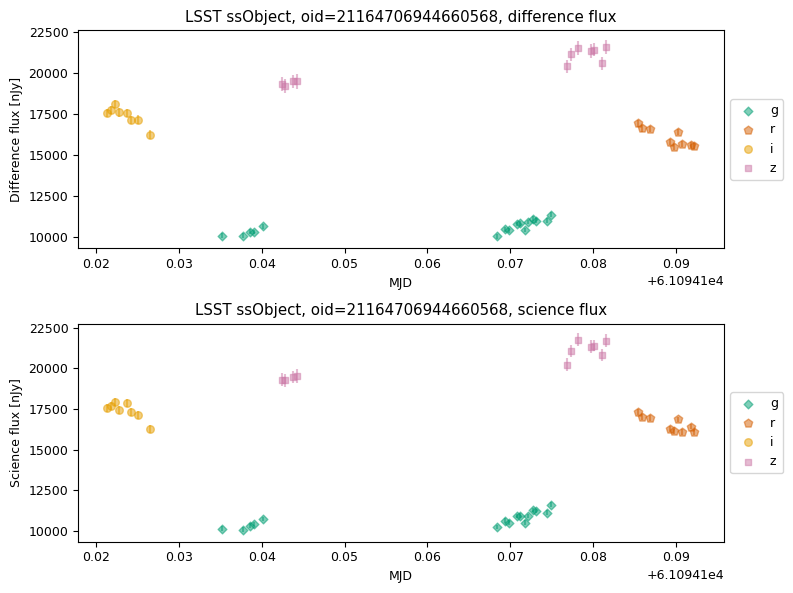

In [27]:
ms.plot_lc(d_objs=d_objs, lc_params=lc_params)

We can show these light curves using magnitude units

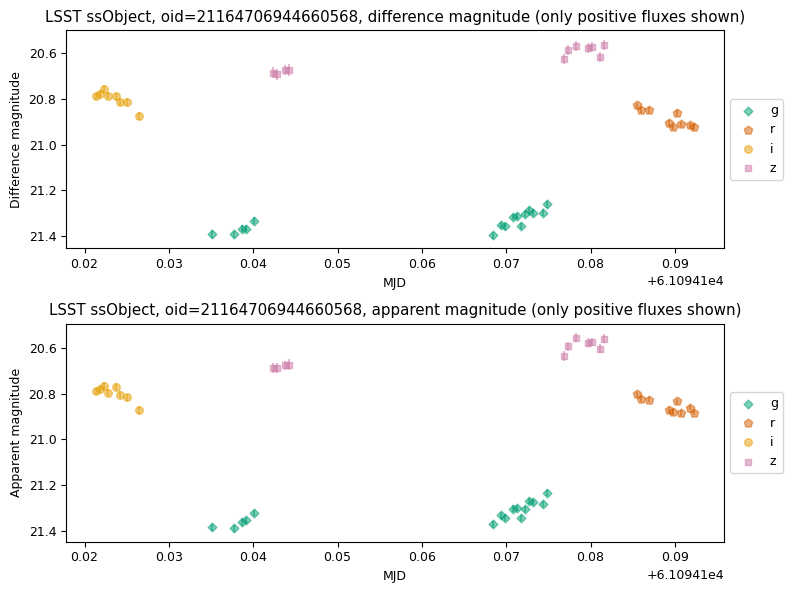

In [28]:
d_objs[sid][oid]['lc_kwargs']['show_flux'] = False

ms.plot_lc(d_objs=d_objs, lc_params=lc_params)

#### Stamps <a class='anchor' id='stamps'></a>

We show alert image cutouts for the first 2 detections of this object that triggered alerts. Note that not all stored detections may have triggered an alert, as they may come in an alert as previous detections. The field ```has_stamp``` in our detections dataframe indicates that a given detection triggered an alert, so that we can use it as a mask as

In [29]:
mask = epochs['detections']['has_stamp']
df_dets_this = epochs['detections'][mask].sort_values(by='mjd').iloc[0:2].copy()

cols = ['sid', 'measurement_id', 'band_name', 'mjd',
        'psfFlux', 'psfFluxErr', 'scienceFlux', 'scienceFluxErr',
        'has_stamp']
cols = [x.lower() for x in cols]
display(df_dets_this[cols])

,sid,measurement_id,band_name,mjd,psfflux,psffluxerr,scienceflux,sciencefluxerr,has_stamp
oid,,,,,,,,,
21164706944660568,2,170046090036381187,i,61094.121367,17558.101562,259.099884,17540.792969,240.052307,True
21164706944660568,2,170046090174268058,i,61094.121833,17737.625000,255.424652,17709.146484,241.552261,True


We use the ALeRCE client to retrieve the stamps, obtaining the main fields: Science, Template and Difference

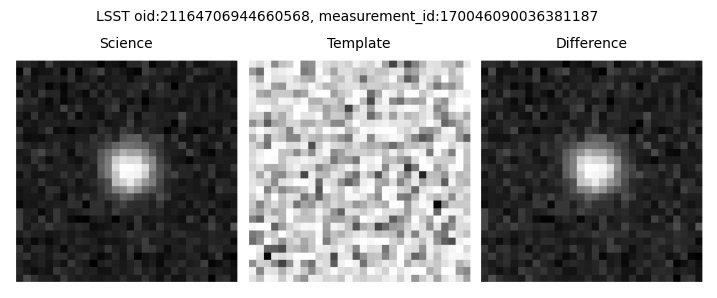

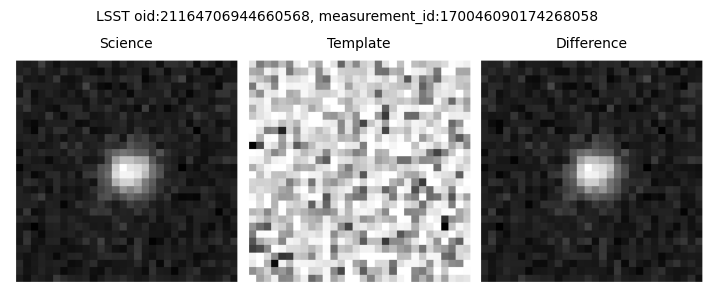

In [30]:
for i, row in df_dets_this.iterrows():
    params = {
        'survey': 'lsst',
        'oid': i,
        'measurement_id': row['measurement_id'],
    }
    df_stamps = alerce_client.plot_stamps(**params)

An extended use of the ALeRCE client to query stamps, including all cutout planes and headers (which include WCS) is presented in [this notebook](https://github.com/alercebroker/usecases/tree/master/notebooks/LSST/ALeRCE_LSST_Client_Queries.ipynb).

#### Epoch data from the ssSource alert field <a class='anchor' id='sssource'></a>

We retrieve additional information for this object from the ssSource alert field, which is stored in our ```lsst_ss_detection``` table

In [31]:
query = '''
SELECT
    *
FROM
    alerce_tap.lsst_ss_detection
WHERE
    ssObjectId = %d
''' % oid
df_ssd = alerce_tap.search(query).to_table().to_pandas()

display(df_ssd)

,measurement_id,ssobjectid,designation,ecllambda,eclbeta,gallon,gallat,elongation,phaseangle,toporange,toporangerate,heliorange,heliorangerate,ephra,ephdec,ephvmag,ephrate,ephratera,ephratedec,ephoffset,ephoffsetra,ephoffsetdec,ephoffsetalongtrack,ephoffsetcrosstrack,helio_x,helio_y,helio_z,helio_vx,helio_vy,helio_vz,helio_vtot,topo_x,topo_y,topo_z,topo_vx,topo_vy,topo_vz,topo_vtot,diadistancerank,created_date
0,170046105910248306,21164706944660568,K10W64X,149.890162,-8.479454,234.479005,41.984603,170.497070,4.212196,8.303132e-09,0.0,1.486647e-08,0.000882,149.014192,3.557897,0.0,0.0,0.0,0.0,0.030702,0.028133,-0.012293,NaN,NaN,-1.305945e-08,6.907087e-09,1.659770e-09,-0.006322,-0.008965,-0.004538,0.014168,-7.104513e-09,4.266427e-09,5.152684e-10,0.001552,0.005513,0.001651,0.007950,1,2026-02-23
1,170046106064912709,21164706944660568,K10W64X,149.890037,-8.479470,234.478883,41.984518,170.496796,4.212320,8.303137e-09,0.0,1.486648e-08,0.000882,149.014073,3.557931,0.0,0.0,0.0,0.0,0.038365,0.019110,-0.033267,NaN,NaN,-1.305947e-08,6.907059e-09,1.659755e-09,-0.006322,-0.008965,-0.004538,0.014168,-7.104508e-09,4.266444e-09,5.152736e-10,0.001551,0.005514,0.001651,0.007950,1,2026-02-23
2,170046105617695137,21164706944660568,K10W64X,149.890451,-8.479438,234.479304,41.984783,170.497726,4.211909,8.303120e-09,0.0,1.486647e-08,0.000882,149.014470,3.557819,0.0,0.0,0.0,0.0,0.035255,0.015834,-0.031499,NaN,NaN,-1.305941e-08,6.907152e-09,1.659803e-09,-0.006322,-0.008965,-0.004538,0.014168,-7.104524e-09,4.266387e-09,5.152564e-10,0.001553,0.005513,0.001651,0.007949,1,2026-02-23
3,170046105481904203,21164706944660568,K10W64X,149.890577,-8.479422,234.479428,41.984870,170.498001,4.211786,8.303115e-09,0.0,1.486646e-08,0.000882,149.014590,3.557786,0.0,0.0,0.0,0.0,0.032169,0.030415,-0.010476,NaN,NaN,-1.305939e-08,6.907180e-09,1.659817e-09,-0.006323,-0.008965,-0.004538,0.014168,-7.104529e-09,4.266369e-09,5.152513e-10,0.001554,0.005512,0.001651,0.007949,1,2026-02-23
4,170046105347688149,21164706944660568,K10W64X,149.890705,-8.479411,234.479557,41.984953,170.498291,4.211658,8.303110e-09,0.0,1.486646e-08,0.000882,149.014713,3.557751,0.0,0.0,0.0,0.0,0.028163,0.027410,-0.006466,NaN,NaN,-1.305937e-08,6.907209e-09,1.659831e-09,-0.006323,-0.008965,-0.004538,0.014168,-7.104533e-09,4.266352e-09,5.152460e-10,0.001555,0.005512,0.001651,0.007948,1,2026-02-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39,170046101098858440,21164706944660568,K10W64X,149.895651,-8.479035,234.484594,41.988124,170.509399,4.206783,8.302913e-09,0.0,1.486635e-08,0.000882,149.019439,3.556424,0.0,0.0,0.0,0.0,0.053405,0.043714,-0.030679,NaN,NaN,-1.305858e-08,6.908318e-09,1.660393e-09,-0.006324,-0.008965,-0.004537,0.014168,-7.104727e-09,4.265671e-09,5.150418e-10,0.001581,0.005495,0.001650,0.007931,1,2026-02-23
40,170046101233074907,21164706944660568,K10W64X,149.895507,-8.479053,234.484453,41.988026,170.509094,4.206917,8.302918e-09,0.0,1.486635e-08,0.000882,149.019309,3.556461,0.0,0.0,0.0,0.0,0.047604,0.008088,-0.046912,NaN,NaN,-1.305861e-08,6.908287e-09,1.660377e-09,-0.006323,-0.008965,-0.004537,0.014168,-7.104722e-09,4.265690e-09,5.150474e-10,0.001581,0.005496,0.001650,0.007931,1,2026-02-23
41,170046101366767745,21164706944660568,K10W64X,149.895386,-8.479064,234.484331,41.987947,170.508820,4.207039,8.302924e-09,0.0,1.486636e-08,0.000882,149.019190,3.556494,0.0,0.0,0.0,0.0,0.057169,0.018728,-0.054014,NaN,NaN,-1.305863e-08,6.908259e-09,1.660363e-09,-0.006323,-0.008965,-0.004537,0.014168,-7.104717e-09,4.265707e-09,5.150526e-10,0.001580,0.005496,0.001650,0.007932,1,2026-02-23
42,170046101501509930,21164706944660568,K10W64X,149.895254,-8.479068,234.484192,41.987867,170.508514,4.207170,8.302929e-09,0.0,1.486636e-08,0.000882,149.019063,3.556530,0.0,0.0,0.0,0.0,0.045757,0.029729,-0.034784,NaN,NaN,-1.305865e-08,6.908230e-09,1.660348e-09,-0.006323,-0.008965,-0.004537,0.014168,-7.104712e-09,4

We show its detections coordinates in different systems, colored by MJD and difference flux. For this we define a function and merge epoch tables

In [32]:
def plot_scatter(df=None, title='', prop_x=None, prop_y=None,
                 prop_color=None, figsize=(6, 3), alpha=0.7):
    fontsize = 9
    plt.rcParams.update({'font.size': fontsize})
    
    fig, ax = plt.subplots(figsize=figsize)

    if prop_color is None:
        sc = ax.scatter(df[prop_x], df[prop_y], s=3, alpha=alpha)
    else:
        cmap = 'coolwarm'
        sc = ax.scatter(df[prop_x], df[prop_y],
                        c=df[prop_color],
                        cmap=cmap, s=10, alpha=alpha)
        plt.colorbar(sc, ax=ax, label=prop_color)
    
    ax.set_xlabel(prop_x)
    ax.set_ylabel(prop_y)
    ax.set_title(title)
    
    plt.tight_layout()
    plt.rcParams.update({'font.size': 12})

In [33]:
cols = ['ssObjectId', 'measurement_id']
cols = [x.lower() for x in cols]

df_dets_sso = pd.merge(df_dets.reset_index(), df_ssd,
                       on=cols)
col = 'created_date'
df_dets_sso = df_dets_sso.drop(
    columns=[col + '_x']).rename(columns={col + '_y': col}).copy()
del df_dets, df_ssd

display(df_dets_sso)

,oid,sid,measurement_id,mjd,ra,dec,band,parentdiasourceid,visit,detector,diaobjectid,ssobjectid,raerr,decerr,ra_dec_cov,x,xerr,y,yerr,centroid_flag,apflux,apfluxerr,apflux_flag,apflux_flag_aperturetruncated,isnegative,snr,psfflux,psffluxerr,psflnl,psfchi2,psfndata,psfflux_flag,psfflux_flag_edge,psfflux_flag_nogoodpixels,trailflux,trailfluxerr,trailra,trailraerr,traildec,traildecerr,traillength,traillengtherr,trailangle,trailangleerr,trailchi2,trailndata,trail_flag_edge,dipolemeanflux,dipolemeanfluxerr,dipolefluxdiff,dipolefluxdifferr,dipolelength,dipoleangle,dipolechi2,dipolendata,scienceflux,sciencefluxerr,forced_psfflux_flag,forced_psfflux_flag_edge,forced_psfflux_flag_nogoodpixels,templateflux,templatefluxerr,ixx,iyy,ixy,ixxpsf,iyypsf,ixypsf,shape_flag,shape_flag_no_pixels,shape_flag_not_contained,shape_flag_parent_source,extendedness,reliability,isdipole,dipolefitattempted,timeprocessedmjdtai,timewithdrawnmjdtai,bboxsize,pixelflags,pixelflags_bad,pixelflags_cr,pixelflags_crcenter,pixelflags_edge,pixelflags_nodata,pixelflags_nodatacenter,pixelflags_interpolated,pixelflags_interpolatedcenter,pixelflags_offimage,pixelflags_saturated,pixelflags_saturatedcenter,pixelflags_suspect,pixelflags_suspectcenter,pixelflags_streak,pixelflags_streakcenter,pixelflags_injected,pixelflags_injectedcenter,pixelflags_injected_template,pixelflags_injected_templatecenter,glint_trail,has_stamp,band_name,designation,ecllambda,eclbeta,gallon,gallat,elongation,phaseangle,toporange,toporangerate,heliorange,heliorangerate,ephra,ephdec,ephvmag,ephrate,ephratera,ephratedec,ephoffset,ephoffsetra,ephoffsetdec,ephoffsetalongtrack,ephoffsetcrosstrack,helio_x,helio_y,helio_z,helio_vx,helio_vy,helio_vz,helio_vtot,topo_x,topo_y,topo_z,topo_vx,topo_vy,topo_vz,topo_vtot,diadistancerank,created_date
0,21164706944660568,2,170046090036381187,61094.121367,149.032159,3.552838,3,0,2026022200147,2,0,21164706944660568,0.000003,0.000003,5.892851e-13,1504.886230,0.055542,3163.324463,0.051472,False,18049.800781,605.585083,False,False,False,67.265305,17558.101562,259.099884,NaN,1652.545288,1681,False,False,False,16362.630859,0.665255,149.032159,NaN,3.552841,NaN,0.484204,NaN,86.633049,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,17540.792969,240.052307,False,False,False,-77.734116,37.043621,0.194949,0.182474,0.007917,0.179637,0.159579,-0.011194,False,False,False,False,0.052529,1.000000,False,False,61094.122911,NaN,25,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,i,K10W64X,149.908935,-8.478020,234.498121,41.996643,170.539032,4.193763,8.302403e-09,0.0,1.486606e-08,0.000882,149.032158,3.552844,0.0,0.0,0.0,0.0,0.020999,0.002484,-0.020851,NaN,NaN,-1.305648e-08,6.911306e-09,1.661905e-09,-0.006326,-0.008963,-0.004537,0.014167,-7.105265e-09,4.263848e-09,5.144924e-10,0.001643,0.005439,0.001647,0.007865,1,2026-02-23
1,21164706944660568,2,170046090174268058,61094.121833,149.032045,3.552873,3,0,2026022200148,9,0,21164706944660568,0.000003,0.000003,7.098872e-13,1126.799927,0.049757,1697.654297,0.044436,False,17172.291016,594.708801,False,False,False,68.755989,17737.625000,255.424652,NaN,1805.190918,1681,False,False,False,16755.900391,1.077147,149.032046,NaN,3.552873,NaN,0.587914,NaN,49.654053,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,17709.146484,241.552261,False,False,False,-165.134872,47.248928,0.173242,0.144015,-0.004246,0.179706,0.154266,-0.012234,False,False,False,False,0.010439,1.000000,False,False,61094.123433,NaN,25,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,i,K10W64X,149.908815,-8.478026,234.497997,41.996568,170.538757,4.193884,8.302408e-09,0.0,1.486606e-08,0.000882,149.032039,3.552877,0.0,0.0,0.0,0.0,0.024379,0.018114,-0.016316,NaN,NaN,-1.305650e-08,6.911278e-09,1.661891e-09,-0.006326,-0.008963,-0.004537,0.014167,-7.105260e-09,4.263865e-09,5.144976e-10,0.001643,0.005439,0.001647,0.007866,1,2026-02-23
2,

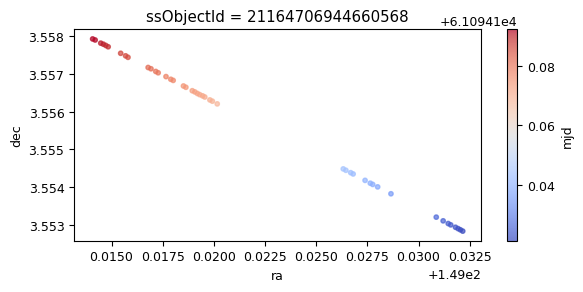

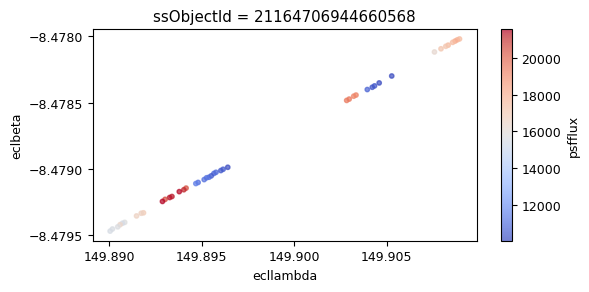

In [34]:
props_x = ['ra', 'eclLambda']
props_x = [x.lower() for x in props_x]
props_y = ['dec', 'eclBeta']
props_y = [x.lower() for x in props_y]
props_color = ['mjd', 'psfFlux']
props_color = [x.lower() for x in props_color]
title = 'ssObjectId = ' + str(oid)

for (prop_x, prop_y, prop_color) in zip(
    props_x, props_y, props_color):
    plot_scatter(df=df_dets_sso, title=title,
                 prop_x=prop_x, prop_y=prop_y,
                 prop_color=prop_color)

## Querying samples of objects <a class='anchor' id='query_many'></a>

Here we show two examples of sample selection: 1) known Solar System objects based on dates of their first and last detections, and 2) candidate moving objects based on classifier probabilities.

### Select ssObjects based on their limit detection dates  <a class='anchor' id='query_sso_many'></a>

We search for ssObjects that had detections in the last five days. For this we define a range of dates by converting the current time to UTC and MJD format, and then subtracting the chosen number of days as

In [35]:
def now_utc(offset_utc=0):
    date_now_local = datetime.now()
    date_now_utc = date_now_local + timedelta(hours=offset_utc)
    date_now_utc = date_now_utc.strftime('%Y-%m-%dT%H:%M:%S')
    
    return date_now_utc

In [36]:
offset_utc = 3. # use 3 (4) for Chile Summer (Winter) time, change for your time zone

In [37]:
date_now_utc = now_utc(offset_utc=offset_utc)
date_now_utc

'2026-03-04T20:00:00'

In [38]:
def utc_to_mjd(time):
    return Time(time, format='isot', scale='utc').mjd

In [39]:
lastmjd_ndays = 5
lastmjd_min = utc_to_mjd(date_now_utc) - lastmjd_ndays
lastmjd_max = utc_to_mjd(date_now_utc)
print('lastmjd limits:', lastmjd_min, lastmjd_max)

lastmjd limits: 61098.833333333336 61103.833333333336


This selection was done on Mar 4 2026, thus an alternative way of selecting these dates is

In [40]:
lastmjd_min = utc_to_mjd('2026-02-27T12:00:00')
lastmjd_max = utc_to_mjd('2026-03-04T12:00:00')
print('lastmjd limits:', lastmjd_min, lastmjd_max)

lastmjd limits: 61098.5 61103.5


We use these values to limit the last detection dates of ssObjects in our ```object``` table. We count the number of expected objects as

In [41]:
sid = 2

In [42]:
query = '''
SELECT
    COUNT(*)
FROM
    alerce_tap.object
WHERE
    sid = %d
    AND lastmjd >= %g
    AND lastmjd < %g
''' % (sid, lastmjd_min, lastmjd_max)

df_n_objs = alerce_tap.search(query).to_table().to_pandas()
print('Number of ssObjects that had their last detection within mjd limits:', df_n_objs.iloc[0, 0])

Number of ssObjects that had their last detection within mjd limits: 401


We now obtain the sample as

In [43]:
query = '''
SELECT
    *
FROM
    alerce_tap.object
WHERE
    sid = %d
    AND lastmjd >= %g
    AND lastmjd < %g
''' % (sid, lastmjd_min, lastmjd_max)

df_objs = alerce_tap.search(query).to_table().to_pandas()
df_objs.set_index('oid', inplace=True)
df_objs.sort_values(by='firstmjd', inplace=True)
display(df_objs)

,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,created_date,updated_date
oid,,,,,,,,,,,,,,
21165819257434182,1,2,150.047267,1.861578,2.135569e-07,2.129165e-07,61094.120903,61099.317816,5.196912,700,0,0,2026-02-23,2026-02-28
20892032238170438,1,2,150.125942,2.580567,1.049016e-08,1.058451e-08,61094.120903,61099.317348,5.196444,761,0,0,2026-02-23,2026-02-28
21164719712317762,1,2,150.303382,2.379774,3.627227e-08,3.657553e-08,61094.120903,61099.317816,5.196912,780,0,0,2026-02-23,2026-02-28
21164724107489875,1,2,151.261802,2.941585,6.214919e-08,6.370961e-08,61094.120903,61099.317816,5.196912,746,0,0,2026-02-23,2026-02-28
21164724126496590,1,2,150.127327,1.641128,1.072365e-07,1.074327e-07,61094.120903,61099.317816,5.196912,790,0,0,2026-02-23,2026-02-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21164706826957658,1,2,151.294909,3.012799,1.043080e-06,1.288428e-06,61099.317348,61099.317816,0.000468,2,0,0,2026-02-28,2026-02-28
21163624394469969,1,2,151.576300,2.923957,8.038605e-06,8.461215e-06,61099.317348,61099.317348,0.000000,1,0,0,2026-02-28,2026-02-28
21164723822540120,1,2,151.579011,1.556340,1.615697e-05,1.873483e-05,61099.317348,61099.317816,0.000468,2,0,0,2026-02-28,2026-02-28


In this example we apply an additional cut, selecting the subset of objects that had their first detection in the last seven days as

In [44]:
firstmjd_ndays = 7
firstmjd_min = utc_to_mjd(date_now_utc) - firstmjd_ndays
print('firstmjd min:', firstmjd_min)

firstmjd min: 61096.833333333336


Or equivalently (as of Mar 4 2026)

In [45]:
firstmjd_min = utc_to_mjd('2026-02-25T12:00:00')
print('firstmjd min:', firstmjd_min)

firstmjd min: 61096.5


In [46]:
mask = df_objs['firstmjd'] >= firstmjd_min
df_objs_recent = df_objs[mask].copy()
display(df_objs_recent)

,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,created_date,updated_date
oid,,,,,,,,,,,,,,
20892066666263640,1,2,151.864993,2.135271,2.771458e-07,2.722455e-07,61097.167046,61099.317348,2.150302,121,0,0,2026-02-26,2026-02-28
21164723855701843,1,2,151.454314,1.304946,1.817392e-07,1.825157e-07,61097.167046,61099.317816,2.150770,203,0,0,2026-02-26,2026-02-28
21163632984602693,1,2,150.983164,0.825905,9.345568e-08,9.599932e-08,61097.167046,61099.317816,2.150770,191,0,0,2026-02-26,2026-02-28
21165831873441874,1,2,150.301259,1.085879,1.775722e-07,1.751326e-07,61097.167046,61099.317816,2.150770,269,0,0,2026-02-26,2026-02-28
21163620287264346,1,2,151.779346,2.323442,7.044589e-08,6.874999e-08,61097.167046,61099.317816,2.150770,206,0,0,2026-02-26,2026-02-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21164706826957658,1,2,151.294909,3.012799,1.043080e-06,1.288428e-06,61099.317348,61099.317816,0.000468,2,0,0,2026-02-28,2026-02-28
21163624394469969,1,2,151.576300,2.923957,8.038605e-06,8.461215e-06,61099.317348,61099.317348,0.000000,1,0,0,2026-02-28,2026-02-28
21164723822540120,1,2,151.579011,1.556340,1.615697e-05,1.873483e-05,61099.317348,61099.317816,0.000468,2,0,0,2026-02-28,2026-02-28


#### Querying detections for larger samples <a class='anchor' id='query_detections_many'></a>

We query the detections for all these objects altogether. For this we define a function that splits the call in smaller chunks, useful for longer object lists

In [47]:
def find_detections(chunk_size=100, index=None, sid=None,
                    maxrec=int(5e5)):
    bin_ids = np.arange(int(np.ceil(len(index) / chunk_size)))
    #print(str(len(bin_ids)) + ' chunks')
    df = pd.DataFrame()
    
    for idx in bin_ids:
        #print('Chunk ' + str(idx))
        index_i = idx * chunk_size
        index_f = (idx + 1) * chunk_size
        names = np.array(index)[index_i:index_f].tolist()
        
        query = '''
        SELECT
            det.*,
            lsst_det.*
        FROM
            alerce_tap.detection AS det
        JOIN
            alerce_tap.lsst_detection AS lsst_det
        ON
            det.oid = lsst_det.oid
            AND det.sid = lsst_det.sid
            AND det.measurement_id = lsst_det.measurement_id
        WHERE
            det.sid = %d
            AND lsst_det.oid IN (%s)
        ''' % (sid, ','.join(["'%s'" % oid for oid in names]))
        df_aux = alerce_tap.search(query, maxrec=maxrec).to_table().to_pandas()
        
        cols = ['oid_', 'sid_', 'measurement_id_', 'created_date_']
        df_aux.drop(columns=cols, inplace=True)

        df = pd.concat([df, df_aux], axis=0)
        del df_aux

    return df

In [48]:
index = df_objs_recent.index
df_dets = find_detections(index=index, sid=sid)

df_dets = add_mapped_column(
    df=df_dets,
    df_lut=df_bands,
    col='band',
    col_mapped='band_name'
)
df_dets.set_index('oid', inplace=True)

In [49]:
display(df_dets[cols_lc])

,sid,measurement_id,band_name,mjd,psfflux,psffluxerr,scienceflux,sciencefluxerr
oid,,,,,,,,
20889833281958467,2,170063690441687096,y,61098.108813,7.511672e+06,6134.174316,7.978302e+06,6392.280273
20889833281958467,2,170068103418347677,y,61099.217476,8.577574e+06,6974.304688,8.961771e+06,7196.536133
20890937038222160,2,170059283587661926,i,61097.188915,2.374935e+05,566.981750,2.372850e+05,547.237610
20890937038222160,2,170059283721880106,i,61097.189381,2.362295e+05,559.459290,2.351433e+05,530.346802
20890937038222160,2,170059284271857772,i,61097.191243,2.378447e+05,589.173340,2.370375e+05,567.495178
...,...,...,...,...,...,...,...,...
23700330444239159,2,170068130403450905,g,61099.315351,2.405750e+05,473.515228,2.467616e+05,483.901062
23700330444239159,2,170068130540814347,i,61099.317348,4.887877e+05,797.770996,4.959051e+05,806.525452
23700330444239159,2,170068130675032065,i,61099.317816,4.896640e+05,818.461792,5.010559e+05,834.247681


Similarly, we obtain their properties from ssSource and latest mpc_orbits alert fields as

In [50]:
def find_ss_detections(chunk_size=100, index=None,
                       maxrec=int(5e5)):
    bin_ids = np.arange(int(np.ceil(len(index) / chunk_size)))
    #print(str(len(bin_ids)) + ' chunks')
    df = pd.DataFrame()
    
    for idx in bin_ids:
        #print('Chunk ' + str(idx))
        index_i = idx * chunk_size
        index_f = (idx + 1) * chunk_size
        names = np.array(index)[index_i:index_f].tolist()
        
        query = '''
        SELECT
            *
        FROM
            alerce_tap.lsst_ss_detection
        WHERE
            ssObjectId IN (%s)
        ''' % ','.join(["'%s'" % oid for oid in names])
        df_aux = alerce_tap.search(query, maxrec=maxrec).to_table().to_pandas()
        
        df = pd.concat([df, df_aux], axis=0)
        del df_aux

    return df

In [51]:
df_ssd = find_ss_detections(index=index)
df_ssd.set_index(col_ssid, inplace=True)
display(df_ssd)

,measurement_id,designation,ecllambda,eclbeta,gallon,gallat,elongation,phaseangle,toporange,toporangerate,heliorange,heliorangerate,ephra,ephdec,ephvmag,ephrate,ephratera,ephratedec,ephoffset,ephoffsetra,ephoffsetdec,ephoffsetalongtrack,ephoffsetcrosstrack,helio_x,helio_y,helio_z,helio_vx,helio_vy,helio_vz,helio_vtot,topo_x,topo_y,topo_z,topo_vx,topo_vy,topo_vz,topo_vtot,diadistancerank,created_date
ssobjectid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
20889833281958467,170063690441687096,J71T02C,151.156857,-7.784577,235.318311,43.278435,169.558655,5.083163,6.976892e-09,0.0,1.354027e-08,-0.000358,150.434275,3.774457,0.0,0.0,0.0,0.0,0.044828,-0.030500,0.032852,NaN,NaN,-1.219921e-08,5.696212e-09,1.439231e-09,-0.005049,-0.010353,-0.005190,0.015487,-6.055270e-09,3.435082e-09,4.592823e-10,0.001819,0.004489,0.001185,0.006603,1,2026-02-27
20889833281958467,170068103418347677,1971 TC2,150.868363,-7.816625,235.023523,43.087336,168.556107,5.569039,6.983880e-09,0.0,1.353765e-08,-0.000351,150.154600,3.844092,0.0,0.0,0.0,0.0,0.057139,-0.029660,0.048838,NaN,NaN,-1.223636e-08,5.619365e-09,1.400735e-09,-0.004977,-0.010386,-0.005199,0.015508,-6.043989e-09,3.467788e-09,4.682114e-10,0.001449,0.004657,0.001224,0.006743,1,2026-02-28
20890937038222160,170059283587661926,J82Q03P,152.665521,-8.049453,237.227893,43.903169,170.762665,3.218684,1.235953e-08,0.0,1.892194e-08,-0.000274,151.742346,3.001192,0.0,0.0,0.0,0.0,0.020028,0.014486,-0.013831,NaN,NaN,-1.697386e-08,8.194630e-09,1.666131e-09,-0.003657,-0.007588,-0.003042,0.011337,-1.087168e-08,5.843437e-09,6.471045e-10,0.003383,0.007232,0.003292,0.010772,1,2026-02-26
20890937038222160,170059283721880106,J82Q03P,152.665392,-8.049455,237.227746,43.903098,170.762375,3.218786,1.235953e-08,0.0,1.892194e-08,-0.000274,151.742231,3.001239,0.0,0.0,0.0,0.0,0.025188,-0.002816,-0.025030,NaN,NaN,-1.697387e-08,8.194606e-09,1.666122e-09,-0.003657,-0.007588,-0.003042,0.011337,-1.087167e-08,5.843459e-09,6.471148e-10,0.003383,0.007232,0.003292,0.010773,1,2026-02-26
20890937038222160,170059284271857772,J82Q03P,152.664891,-8.049437,237.227159,43.902838,170.761215,3.219193,1.235954e-08,0.0,1.892193e-08,-0.000274,151.741770,3.001427,0.0,0.0,0.0,0.0,0.013416,0.007688,-0.010994,NaN,NaN,-1.697391e-08,8.194512e-09,1.666084e-09,-0.003657,-0.007588,-0.003042,0.011337,-1.087163e-08,5.843549e-09,6.471557e-10,0.003380,0.007234,0.003293,0.010774,1,2026-02-26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23700330444239159,170068130403450905,1017 T-3,151.439913,-8.637453,236.298095,42.737542,168.306488,3.666645,1.445824e-08,0.0,2.098538e-08,-0.000526,150.398613,2.877454,0.0,0.0,0.0,0.0,0.047403,-0.036420,0.030342,NaN,NaN,-1.875187e-08,9.274558e-09,1.654123e-09,-0.003413,-0.007379,-0.003993,0.010980,-1.255534e-08,7.132829e-09,7.258028e-10,0.002845,0.007666,0.002435,0.011208,1,2026-02-28
23700330444239159,170068130540814347,1017 T-3,151.439475,-8.637491,236.297638,42.737266,168.304794,3.667170,1.445826e-08,0.0,2.098537e-08,-0.000526,150.398186,2.877579,0.0,0.0,0.0,0.0,0.007759,-0.007180,-0.002941,NaN,NaN,-1.875191e-08,9.274459e-09,1.654070e-09,-0.003413,-0.007379,-0.003993,0.010980,-1.255530e-08,7.132932e-09,7.258353e-10,0.002841,0.007665,0.002435,0.011206,1,2026-02-28
23700330444239159,170068130675032065,1017 T-3,151.439372,-8.637498,236.297530,42.737202,168.304413,3.667293,1.445826e-08,0.0,2.098537e-08,-0.000526,150.398086,2.877609,0.0,0.0,0.0,0.0,0.005859,-0.000654,-0.005823,NaN,NaN,-1.875192e-08,9.274436e-09,1.654057e-09,-0.003413,-0.007379,-0.003993,0.010980,-1.255530e-08,7.132956e-09,7.258429e-10,0.002841,0.007665,0.002435,0.011206,1,2026-02-28


In [52]:
query = '''
SELECT
    *
FROM
    alerce_tap.lsst_mpc_orbits
WHERE
    ssObjectId IN (%s)
''' % ','.join(["'%s'" % oid for oid in index])

df_mpc = alerce_tap.search(query).to_table().to_pandas()
df_mpc.set_index(col_ssid, inplace=True)
display(df_mpc)

,designation,packed_primary_provisional_designation,unpacked_primary_provisional_designation,mpc_orb_jsonb,created_at,updated_at,orbit_type_int,u_param,nopp,arc_length_total,arc_length_sel,nobs_total,nobs_total_sel,a,q,e,i,node,argperi,peri_time,yarkovsky,srp,a1,a2,a3,dt,mean_anomaly,period,mean_motion,a_unc,q_unc,e_unc,i_unc,node_unc,argperi_unc,peri_time_unc,yarkovsky_unc,srp_unc,a1_unc,a2_unc,a3_unc,dt_unc,mean_anomaly_unc,period_unc,mean_motion_unc,epoch_mjd,h,g,not_normalized_rms,normalized_rms,earth_moid,fitting_datetime,created_date,updated_date
ssobjectid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
20889833281958467,1971 TC2,J71T02C,1971 TC2,"{""CAR"": {""covariance"": {""cov00"": 0.0000000000000009659890518239434, ""cov01"": 0.00000000000000069...",1970-01-01,1970-01-01,-1,0,33,30781.539526,30781.539526,8508,8358,2.232654,2.016203,0.096948,5.027760,281.870108,251.434435,59931.387977,0.0,0.0,0.0,0.0,0.0,0.0,315.712675,1218.514044,0.295442,1.510600e-09,1.310470e-08,5.845990e-09,5.584820e-07,0.000008,0.000009,0.000012,0.0,0.0,0.0,0.0,0.0,0.0,0.000004,0.000001,2.998420e-10,61000.0,12.212,0.15,0.0,0.544271,0.00000,1970-01-01,2026-02-28,2026-02-28
20890937038222160,1982 QP3,J82Q03P,1982 QP3,"{""CAR"": {""covariance"": {""cov00"": 0.000000000000001737130267600354, ""cov01"": 0.000000000000001627...",1970-01-01,1970-01-01,-1,0,21,15886.517286,15886.517286,3944,3877,2.296633,1.758247,0.234424,5.407537,230.320272,98.156861,60429.854324,0.0,0.0,0.0,0.0,0.0,0.0,161.455420,1271.263882,0.283183,1.906450e-09,1.728480e-08,7.612470e-09,1.128610e-06,0.000009,0.000009,0.000009,0.0,0.0,0.0,0.0,0.0,0.0,0.000003,0.000002,3.526085e-10,61000.0,14.384,0.15,0.0,0.699525,0.00000,1970-01-01,2026-02-28,2026-02-28
20890966935221318,1989 GF4,J89G04F,1989 GF4,"{""CAR"": {""covariance"": {""cov00"": 0.000000000000001950409850971642, ""cov01"": 0.000000000000001636...",1970-01-01,1970-01-01,-1,0,28,16194.046165,16192.961095,4406,4301,2.797785,2.165147,0.226121,6.567767,217.492720,83.472589,60005.945223,0.0,0.0,0.0,0.0,0.0,0.0,209.359609,1709.306403,0.210612,3.607560e-09,2.004330e-08,6.994420e-09,9.063350e-07,0.000008,0.000008,0.000010,0.0,0.0,0.0,0.0,0.0,0.0,0.000002,0.000003,4.073552e-10,61000.0,13.173,0.15,0.0,0.740878,0.00000,1970-01-01,2026-02-28,2026-02-28
20892058142126662,1997 XF2,J97X02F,1997 XF2,"{""CAR"": {""covariance"": {""cov00"": 0.000000000000004608209660024578, ""cov01"": 0.000000000000003465...",1970-01-01,1970-01-01,-1,0,24,10310.880160,10310.880160,2320,2262,3.071429,2.798271,0.088935,8.309190,269.811615,30.392332,61859.833479,0.0,0.0,0.0,0.0,0.0,0.0,202.562702,1966.116397,0.183102,6.098610e-09,3.274680e-08,1.091490e-08,9.501540e-07,0.000010,0.000013,0.000048,0.0,0.0,0.0,0.0,0.0,0.0,0.000009,0.000006,5.453494e-10,61000.0,13.876,0.15,0.0,0.784640,0.00000,1970-01-01,2026-02-28,2026-02-28
20892062437618501,1998 XE83,J98X83E,1998 XE83,"{""CAR"": {""covariance"": {""cov00"": 0.000000000000004662758366281234, ""cov01"": 0.000000000000003598...",1970-01-01,1970-01-01,-1,0,22,11253.318480,11253.297010,2585,2522,3.026619,2.587158,0.145199,11.574062,191.514353,258.398985,60833.607340,0.0,0.0,0.0,0.0,0.0,0.0,31.145958,1923.246573,0.187183,5.392180e-09,2.756460e-08,8.919720e-09,1.126480e-06,0.000005,0.000006,0.000019,0.0,0.0,0.0,0.0,0.0,0.0,0.000004,0.000005,5.002255e-10,61000.0,14.086,0.15,0.0,0.788903,0.00000,1970-01-01,2026-02-28,2026-02-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21165819273689426,2023 SR9,K23S09R,2023 SR9,"{""CAR"": {""covariance"": {""cov00"": 0.00000000000007951521059985507, ""cov01"": 0.0000000000000702460...",1970-01-01,1970-01-01,-1,0,6,4022.985474,4022.985474,64,64,3.069262,2.975506,0.030547,8.531666,278.869813,65.547909,62136.167967,0.0,0.0,0.0,0.0,0.0,0.0,151.744922,1964.035988,0.183296,4.375250e-08,2.134050e-07,7.415290e-08,5.84

We list all unpacked designations returned by this query

In [53]:
print(np.sort(pd.unique(df_mpc['designation'])))

['1017 T-3' '1971 TC2' '1982 QP3' '1989 GF4' '1997 XF2' '1998 XE83'
 '1999 TX134' '1999 VV157' '2000 AZ240' '2000 HH27' '2000 SU28'
 '2000 VK37' '2000 VK54' '2001 FM186' '2001 FR56' '2001 OH' '2001 OU47'
 '2001 RB34' '2001 SM285' '2001 UB121' '2001 VC86' '2001 VP54' '2002 LP19'
 '2002 NS31' '2002 RR210' '2002 TU260' '2002 VC108' '2003 AW5'
 '2003 SD366' '2003 UK31' '2003 UO310' '2003 UY77' '2003 UZ376'
 '2004 JQ12' '2004 XU11' '2005 JZ37' '2005 QT102' '2005 SY' '2005 UD157'
 '2006 JE48' '2006 QA166' '2006 QV41' '2006 RB14' '2006 SW264'
 '2006 WX193' '2007 UF78' '2008 UH2' '2008 YM11' '2009 BZ9' '2009 CK53'
 '2009 DD52' '2010 PZ23' '2010 UA111' '2010 VT225' '2010 VW272'
 '2010 XX105' '2011 BV137' '2011 QZ' '2011 RS39' '2011 SN255' '2012 DS132'
 '2012 TU1' '2012 XF173' '2013 CB96' '2013 CR63' '2013 EJ153' '2013 HT120'
 '2013 TV166' '2014 ED117' '2014 EX65' '2014 GS7' '2014 NV18' '2014 QO41'
 '2014 RA6' '2014 RW62' '2014 WD242' '2014 YW51' '2015 DN202' '2015 DP237'
 '2015 FJ430' '2015 SM5

We show their detections coordinates as before

In [54]:
cols = ['ssObjectId', 'measurement_id']
cols = [x.lower() for x in cols]

df_dets_sso = pd.merge(df_dets.reset_index(), df_ssd,
                       on=cols)
col = 'created_date'
df_dets_sso = df_dets_sso.drop(
    columns=[col + '_x']).rename(columns={col + '_y': col}).copy()
del df_dets, df_ssd

display(df_dets_sso)

,oid,sid,measurement_id,mjd,ra,dec,band,parentdiasourceid,visit,detector,diaobjectid,ssobjectid,raerr,decerr,ra_dec_cov,x,xerr,y,yerr,centroid_flag,apflux,apfluxerr,apflux_flag,apflux_flag_aperturetruncated,isnegative,snr,psfflux,psffluxerr,psflnl,psfchi2,psfndata,psfflux_flag,psfflux_flag_edge,psfflux_flag_nogoodpixels,trailflux,trailfluxerr,trailra,trailraerr,traildec,traildecerr,traillength,traillengtherr,trailangle,trailangleerr,trailchi2,trailndata,trail_flag_edge,dipolemeanflux,dipolemeanfluxerr,dipolefluxdiff,dipolefluxdifferr,dipolelength,dipoleangle,dipolechi2,dipolendata,scienceflux,sciencefluxerr,forced_psfflux_flag,forced_psfflux_flag_edge,forced_psfflux_flag_nogoodpixels,templateflux,templatefluxerr,ixx,iyy,ixy,ixxpsf,iyypsf,ixypsf,shape_flag,shape_flag_no_pixels,shape_flag_not_contained,shape_flag_parent_source,extendedness,reliability,isdipole,dipolefitattempted,timeprocessedmjdtai,timewithdrawnmjdtai,bboxsize,pixelflags,pixelflags_bad,pixelflags_cr,pixelflags_crcenter,pixelflags_edge,pixelflags_nodata,pixelflags_nodatacenter,pixelflags_interpolated,pixelflags_interpolatedcenter,pixelflags_offimage,pixelflags_saturated,pixelflags_saturatedcenter,pixelflags_suspect,pixelflags_suspectcenter,pixelflags_streak,pixelflags_streakcenter,pixelflags_injected,pixelflags_injectedcenter,pixelflags_injected_template,pixelflags_injected_templatecenter,glint_trail,has_stamp,band_name,designation,ecllambda,eclbeta,gallon,gallat,elongation,phaseangle,toporange,toporangerate,heliorange,heliorangerate,ephra,ephdec,ephvmag,ephrate,ephratera,ephratedec,ephoffset,ephoffsetra,ephoffsetdec,ephoffsetalongtrack,ephoffsetcrosstrack,helio_x,helio_y,helio_z,helio_vx,helio_vy,helio_vz,helio_vtot,topo_x,topo_y,topo_z,topo_vx,topo_vy,topo_vz,topo_vtot,diadistancerank,created_date
0,20889833281958467,2,170063690441687096,61098.108813,150.434267,3.774466,5,0,2026022600208,63,0,20889833281958467,1.570864e-07,1.657277e-07,-6.006231e-15,1316.924316,0.002543,1185.568604,0.003236,False,7.934164e+06,5752.010742,False,False,False,1227.838623,7.511672e+06,6134.174316,NaN,17289.363281,1681,False,False,False,7.395402e+06,26.796814,150.434265,NaN,3.774470,NaN,0.827566,NaN,122.665207,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,7.978302e+06,6392.280273,False,False,False,-855.626831,370.684113,0.180833,0.229755,0.019148,0.154456,0.213919,0.019405,False,False,False,False,0.058823,1.000000,False,False,61098.110278,NaN,79,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,y,J71T02C,151.156857,-7.784577,235.318311,43.278435,169.558655,5.083163,6.976892e-09,0.0,1.354027e-08,-0.000358,150.434275,3.774457,0.0,0.0,0.0,0.0,0.044828,-0.030500,0.032852,NaN,NaN,-1.219921e-08,5.696212e-09,1.439231e-09,-0.005049,-0.010353,-0.005190,0.015487,-6.055270e-09,3.435082e-09,4.592823e-10,0.001819,0.004489,0.001185,0.006603,1,2026-02-27
1,20889833281958467,2,170068103418347677,61099.217476,150.154591,3.844105,5,0,2026022700319,124,0,20889833281958467,1.641730e-07,1.892033e-07,-4.184876e-16,547.639648,0.003414,1286.215942,0.002958,False,8.843855e+06,6985.712891,False,False,False,1222.513184,8.577574e+06,6974.304688,NaN,7864.970215,1681,False,False,False,8.035274e+06,1.566669,150.154589,NaN,3.844106,NaN,0.735769,NaN,-19.309900,NaN,NaN,0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.961771e+06,7196.536133,False,False,False,-834.781555,372.184357,0.267019,0.226827,-0.012831,0.251128,0.209787,-0.001292,False,False,False,False,0.029085,1.000000,False,False,61099.218772,NaN,71,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,y,1971 TC2,150.868363,-7.816625,235.023523,43.087336,168.556107,5.569039,6.983880e-09,0.0,1.353765e-08,-0.000351,150.154600,3.844092,0.0,0.0,0.0,0.0,0.057139,-0.029660,0.048838,NaN,NaN,-1.223636e-08,5.619365e-09,1.400735e-09,-0.004977,-0.010386,-0.005199,0.015508,-6.043989e-09,3.467788e-09,4.682114e-10,0.001449,0.0

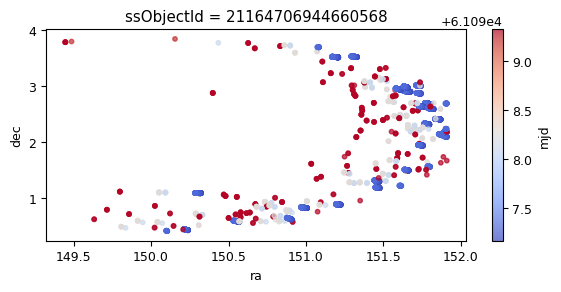

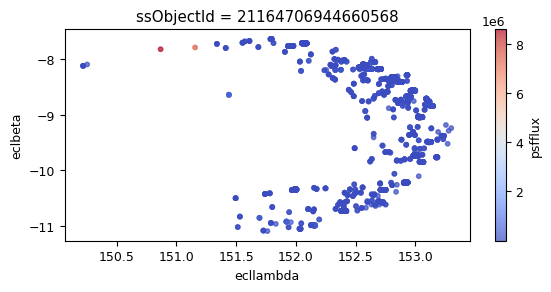

In [55]:
props_x = ['ra', 'eclLambda']
props_x = [x.lower() for x in props_x]
props_y = ['dec', 'eclBeta']
props_y = [x.lower() for x in props_y]
props_color = ['mjd', 'psfFlux']
props_color = [x.lower() for x in props_color]
title = 'ssObjectId = ' + str(oid)

for (prop_x, prop_y, prop_color) in zip(
    props_x, props_y, props_color):
    plot_scatter(df=df_dets_sso, title=title,
                 prop_x=prop_x, prop_y=prop_y,
                 prop_color=prop_color)

#### Distributions of ssSource properties  <a class='anchor' id='query_sso_many'></a>

We show their distributions of several properties as

In [56]:
def plot_cols_hist(df=None, cols=None, bins=None, xlims=None,
                   title='', figsize=(6, 3)):
    fontsize = 9
    alpha = 0.7
    
    plt.rcParams.update({'font.size': fontsize})
    
    for col in cols:
        fig, ax = plt.subplots(figsize=figsize)
        ax.hist(df[col], bins=bins, range=xlims, alpha=alpha)
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')
        ax.set_yscale('log')
        ax.set_title(title)
        
        plt.tight_layout()
    
    plt.rcParams.update({'font.size': 12})

101 ssObjectIds


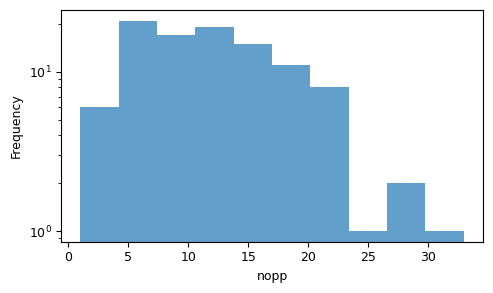

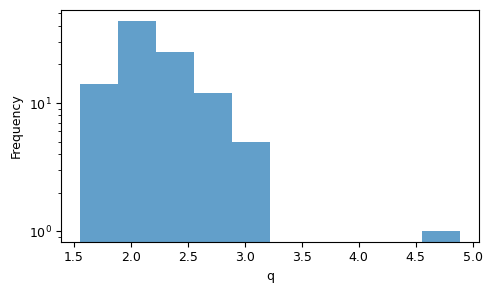

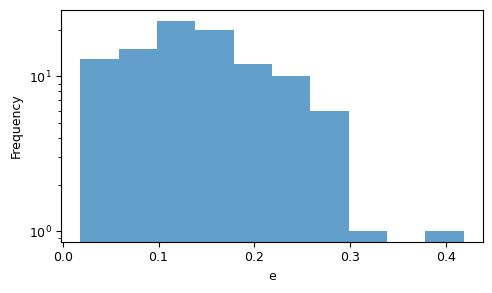

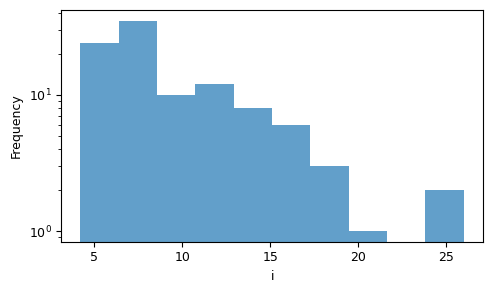

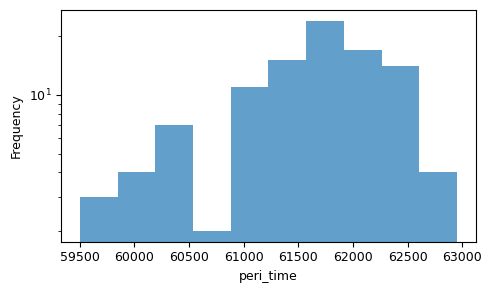

In [57]:
cols = ['nopp', 'q', 'e', 'i', 'peri_time']
print(str(len(df_mpc)) + ' ssObjectIds')
plot_cols_hist(df=df_mpc, cols=cols, figsize=(5, 3))

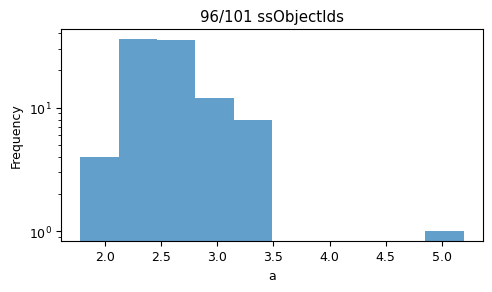

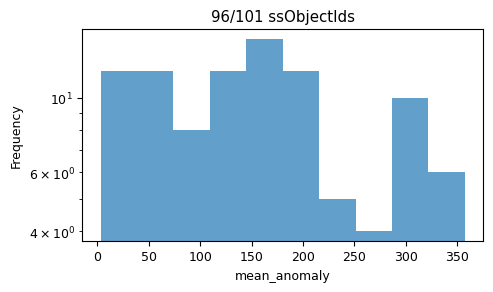

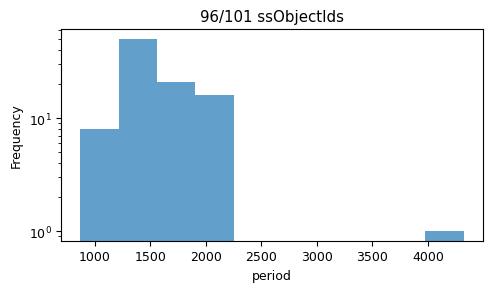

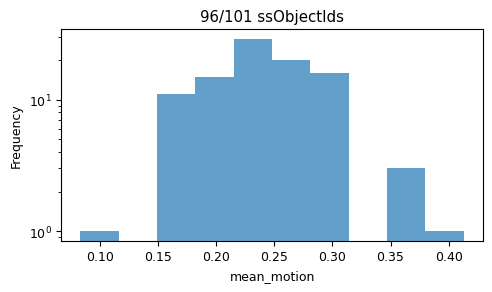

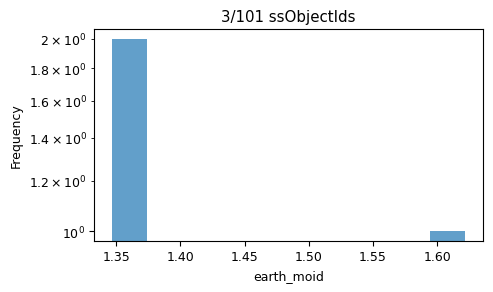

In [58]:
cols = ['a', 'mean_anomaly', 'period', 'mean_motion', 'earth_moid']
for col in cols:
    mask = df_mpc[col] != 0
    title = str(len(df_mpc[mask])) + '/' + str(len(df_mpc)) + ' ssObjectIds'
    plot_cols_hist(df=df_mpc[mask], cols=[col], title=title, figsize=(5, 3))

### Select asteroid candidates based on stamp classifier probabilities  <a class='anchor' id='query_classifier_many'></a>

The ALeRCE pipeline computes probabilities for different classifiers. At this time, we classify LSST objects using the ALeRCE stamp classifier (still in beta mode), which is a deep learning classifier based on each object's first alert image cutouts (manuscript in preparation; see [Carrasco-Davis et al. 2021](https://ui.adsabs.harvard.edu/abs/2021AJ....162..231C/abstract) for a similar version using the ZTF public alert stream). This classifier taxonomy includes five classes, and is used to pre-select transient candidates (e.g. supernovae, tidal disruption events) early after their first light.

In this classifier, known Solar System objects are assigned a probability 1 to be an asteroid. However, not-yet-reported moving objects that trigger LSST alerts are assigned diaObjectIds, thus we can use our stamp classifier to search for asteroid candidates based on their probabilities and spatial coordinates (each diaObject is classified independently, so classifications are not aware of how close or aligned different diaObjects may be in the plane of the sky).

Note that we use integer identifiers for both classifiers and their taxonomies. We recover the classifier and class names using the mapping defined in the ```classifier``` and ```taxonomy``` LUTs, respectively:

In [59]:
table_name = 'classifier'

query = '''
SELECT
    classifier_id, classifier_name, classifier_version, tid
FROM
    alerce_tap.%s
WHERE
    tid = %d
''' % (table_name, tid)

df_classifiers = alerce_tap.search(query).to_table().to_pandas()
display(df_classifiers)

,classifier_id,classifier_name,classifier_version,tid
0,1,stamp_classifier_rubin,2.0.1,1


In [60]:
classifier_id = 1 # Stamp classifier

In [61]:
table_name = 'taxonomy'

query = '''
SELECT
    class_id, class_name, classifier_id
FROM
    alerce_tap.%s
WHERE
    classifier_id = %d
''' % (table_name, classifier_id)

df_tax_stamp = alerce_tap.search(query).to_table().to_pandas()
display(df_tax_stamp)

,class_id,class_name,classifier_id
0,0,SN,1
1,1,AGN,1
2,2,VS,1
3,3,asteroid,1
4,4,bogus,1


We search for 1000 diaObjects that had their first detection between Feb 27 2026 and Feb 28 2026, have a difference between last and first detection date of less than 1 day, and have the highest probability of being an asteroid according to the stamp classifier, as

In [62]:
firstmjd_min = utc_to_mjd('2026-02-27T00:00:00')
firstmjd_max = utc_to_mjd('2026-02-28T00:00:00')
print(firstmjd_min, firstmjd_max)

61098.0 61099.0


In [63]:
sid = 1
class_id = 3 # asteroid
n_objs = 1000

In [64]:
query = '''
SELECT TOP %d
    obj.*,
    prob.*
FROM
    alerce_tap.object AS obj
JOIN
    alerce_tap.probability AS prob
ON
    obj.oid = prob.oid
    AND obj.sid = prob.sid
WHERE
    obj.sid = %d
    AND obj.firstmjd >= %g
    AND obj.firstmjd < %g
    AND obj.lastmjd - obj.firstmjd < 1
    AND prob.classifier_id = %d
    AND prob.class_id = %d
    AND prob.ranking = 1
ORDER BY prob.probability DESC
''' % (n_objs, sid,
       firstmjd_min, firstmjd_max,
       classifier_id, class_id)
df_objs = alerce_tap.search(query).to_table().to_pandas()

cols = ['oid_', 'sid_', 'lastmjd_']
df_objs.drop(columns=cols, inplace=True)
#display(df_objs)

We recover both classifier and class names as

In [65]:
df_objs = add_mapped_column(
    df=df_objs,
    df_lut=df_classifiers,
    col='classifier_id',
    col_mapped='classifier_name'
)

df_objs = add_mapped_column(
    df=df_objs,
    df_lut=df_tax_stamp,
    col='class_id',
    col_mapped='class_name'
)

In [66]:
display(df_objs)

,oid,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,created_date,updated_date,classifier_id,classifier_version,class_id,probability,ranking,classifier_name,class_name
0,170063689155608602,1,1,63.816892,-46.424427,4.752252e-05,3.579316e-05,61098.101830,61098.101830,0.000000,1,0,0,2026-02-27,2026-02-27,1,201,3,0.997178,1,stamp_classifier_rubin,asteroid
1,170063689155608621,1,1,63.717535,-46.365545,4.809375e-05,3.068919e-05,61098.101830,61098.101830,0.000000,1,0,0,2026-02-27,2026-02-27,1,201,3,0.997163,1,stamp_classifier_rubin,asteroid
2,170063689381576762,1,1,63.966077,-47.789115,3.817607e-05,8.980625e-06,61098.102698,61098.102698,0.000000,1,0,0,2026-02-27,2026-02-27,1,201,3,0.997139,1,stamp_classifier_rubin,asteroid
3,170063674389561346,1,1,62.968675,-46.215244,3.091988e-05,1.737107e-05,61098.049720,61098.049720,0.000000,1,0,0,2026-02-27,2026-02-27,1,201,3,0.997095,1,stamp_classifier_rubin,asteroid
4,170063676544385027,1,1,62.157976,-46.826673,2.225802e-05,2.978413e-05,61098.057019,61098.057019,0.000000,1,0,0,2026-02-27,2026-02-27,1,201,3,0.997083,1,stamp_classifier_rubin,asteroid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,170063715990241371,1,1,186.704101,8.223739,3.981885e-06,3.913208e-06,61098.236379,61098.239970,0.003591,8,3,0,2026-02-27,2026-02-27,1,201,3,0.944982,1,stamp_classifier_rubin,asteroid
996,170063710823384789,1,1,185.035581,7.981173,5.070639e-06,6.076834e-06,61098.213341,61098.215214,0.001873,5,1,0,2026-02-27,2026-02-27,1,201,3,0.944844,1,stamp_classifier_rubin,asteroid
997,170063723575640317,1,1,151.393581,1.240772,1.482030e-05,1.633868e-05,61098.272697,61098.272697,0.000000,1,0,0,2026-02-27,2026-02-27,1,201,3,0.944832,1,stamp_classifier_rubin,asteroid
998,170063670774595682,1,1,58.509561,-47.534027,8.552440e-07,3.720315e-07,61098.036166,61098.036166,0.000000,1,0,0,2026-02-27,2026-02-27,1,201,3,0.944828,1,stamp_classifier_rubin,asteroid


Note that for each object we compute probabilities in all taxonomy classes, but in this query we were interested only in their most likely class, thus we asked for ```ranking = 1``` probabilities only.

We obtain summary statistics of some of their properties as

In [67]:
cols = ['firstmjd', 'deltamjd', 'n_det']
display(df_objs[cols].describe())

,firstmjd,deltamjd,n_det
count,1000.000000,1000.000000,1000.000000
mean,61098.167310,0.000769,2.432000
std,0.073764,0.001107,2.043906
min,61098.023662,0.000000,1.000000
25%,61098.099141,0.000000,1.000000
50%,61098.194004,0.000000,1.000000
75%,61098.231246,0.001871,4.000000
max,61098.275586,0.004744,9.000000


Note that each of these objects had all detections within seven minutes at most. We display their mean coordinates colored by first detection date as

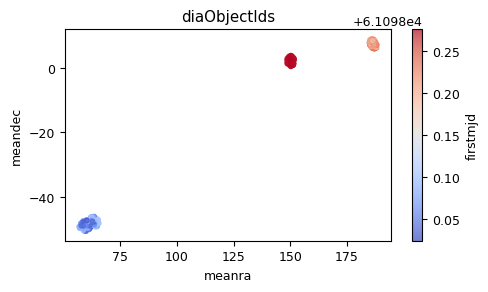

In [68]:
plot_scatter(df=df_objs, title='diaObjectIds',
             prop_x='meanra', prop_y='meandec',
             prop_color='firstmjd',
             figsize=(5, 3))

#### Visual inspection of a candidate tracklet  <a class='anchor' id='tracklet'></a>

We zoom in to one of this three regions, towards the M49 galaxy

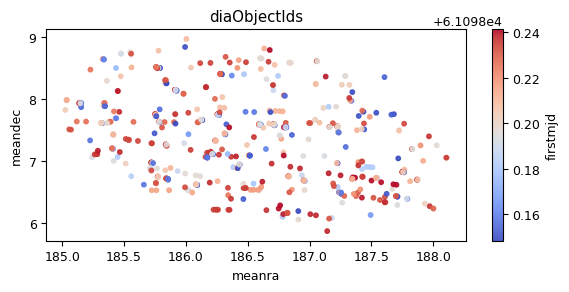

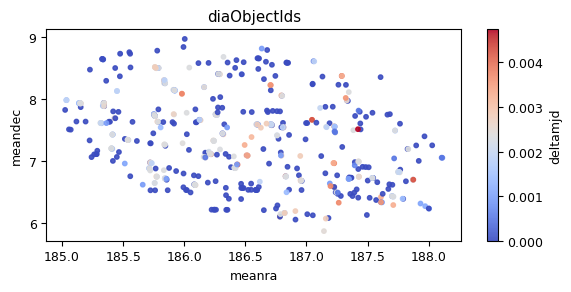

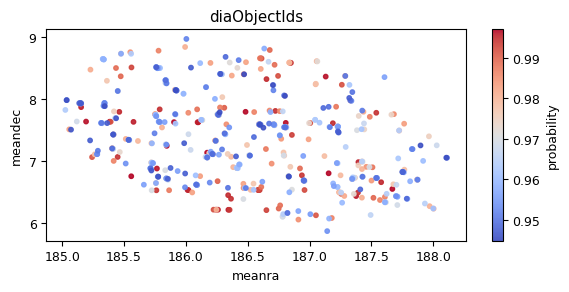

In [69]:
mask = (df_objs['meanra'] > 175) \
       & (df_objs['meandec'] > 0)

props_x = ['meanra', 'meanra', 'meanra']
props_y = ['meandec', 'meandec', 'meandec']
props_color = ['firstmjd', 'deltamjd', 'probability']

title = 'diaObjectIds'

for (prop_x, prop_y, prop_color) in zip(
    props_x, props_y, props_color):
    plot_scatter(df=df_objs[mask], title=title,
                 prop_x=prop_x, prop_y=prop_y,
                 prop_color=prop_color, alpha=0.9)

We can see hints of alignments between different objects. To inspect these in more detail, we define a function that displays subsets of our object sample based on coordinate limits, after selecting a tentative region

In [70]:
def show_tracklet(df=None, ra_lims=None, dec_lims=None, show_table=False):
    mask = (df['meanra'] > ra_lims[0]) \
       & (df['meanra'] < ra_lims[1]) \
       & (df['meandec'] > dec_lims[0]) \
       & (df['meandec'] < dec_lims[1])
    df_track = df[mask].sort_values(by='meanra').copy()
    
    plot_scatter(df=df_track, title='Candidate tracklet',
                 prop_x='meanra', prop_y='meandec',
                 prop_color='firstmjd', alpha=0.9)

    if show_table:
        print(str(len(df_track)) + ' diaObjectIds')
        cols = ['oid', 'meanra', 'meandec', 'firstmjd', 'deltamjd', 'n_det']
        display(df_track[cols])

    return df_track

22 diaObjectIds


,oid,meanra,meandec,firstmjd,deltamjd,n_det
697,170063712293486622,185.772885,8.495780,61098.220247,0.001399,4
792,170063707196883028,185.778703,8.496587,61098.196808,0.001871,5
708,170063701018673156,185.788613,8.497988,61098.157938,0.000470,2
723,170063698333270057,185.790824,8.498270,61098.148357,0.002343,4
770,170063716101390443,185.834300,8.301236,61098.236850,0.003120,6
...,...,...,...,...,...,...
609,170063703306141748,185.920355,8.139331,61098.178373,0.000935,3
469,170063702361899078,185.920835,8.138950,61098.175081,0.001885,5
878,170063702098182150,185.922197,8.137661,61098.166027,0.000466,2
882,170063700767539215,185.923478,8.136544,61098.156996,0.001411,4


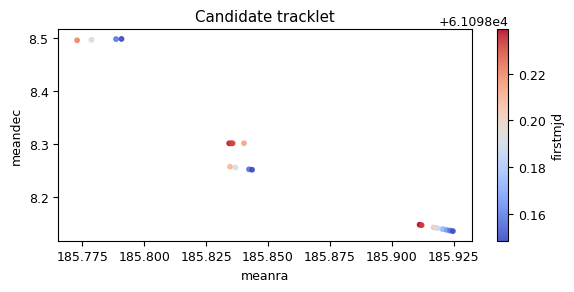

In [71]:
df_track = show_tracklet(
    df=df_objs,
    ra_lims=[185.77, 185.95],
    dec_lims=[8, 8.6],
    show_table=True
)

We zoom in even more, to show only one of these candidate tracklets

10 diaObjectIds


,oid,meanra,meandec,firstmjd,deltamjd,n_det
473,170063716609425490,185.911207,8.147477,61098.239036,0.002336,6
422,170063715137224775,185.912007,8.146776,61098.233574,0.002337,6
888,170063708020539435,185.916826,8.142517,61098.202003,0.001515,4
671,170063706389479472,185.917934,8.141510,61098.194004,0.002338,5
992,170063705603571796,185.918394,8.141125,61098.191128,0.002407,6
609,170063703306141748,185.920355,8.139331,61098.178373,0.000935,3
469,170063702361899078,185.920835,8.138950,61098.175081,0.001885,5
878,170063702098182150,185.922197,8.137661,61098.166027,0.000466,2
882,170063700767539215,185.923478,8.136544,61098.156996,0.001411,4
956,170063698470633548,185.924621,8.135512,61098.148822,0.001877,5


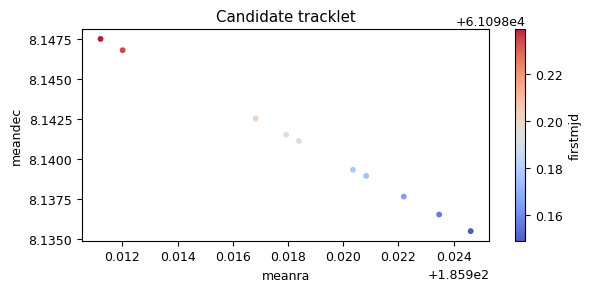

In [72]:
df_track = show_tracklet(
    df=df_objs,
    ra_lims=[185.9, 185.95],
    dec_lims=[8, 8.2],
    show_table=True
)

We query their detections as

In [73]:
index = df_track['oid']
df_dets = find_detections(index=index, sid=sid)

df_dets = add_mapped_column(
    df=df_dets,
    df_lut=df_bands,
    col='band',
    col_mapped='band_name'
)
df_dets.set_index('oid', inplace=True)

In [74]:
display(df_dets[cols_lc])

,sid,measurement_id,band_name,mjd,psfflux,psffluxerr,scienceflux,sciencefluxerr
oid,,,,,,,,
170063698470633548,1,170063698470633548,i,61098.148822,7274.091309,405.286072,7240.071289,401.470367
170063698470633548,1,170063698608521284,i,61098.149290,7069.110352,380.184204,7103.743164,379.914429
170063698470633548,1,170063698758467650,i,61098.149757,7443.635742,345.377838,7517.564453,347.683716
170063698470633548,1,170063698893209646,i,61098.150229,7175.157715,319.692657,7194.117188,322.249115
170063698470633548,1,170063699026903072,i,61098.150699,7584.829590,318.094238,7697.477539,322.243439
...,...,...,...,...,...,...,...,...
170063716609425490,1,170063716744167489,r,61098.239503,6882.749023,206.097122,6931.924316,205.604980
170063716609425490,1,170063716878385203,r,61098.239970,6869.039062,195.464737,6910.844238,194.448441
170063716609425490,1,170063717013127209,r,61098.240440,6471.999512,183.977081,6610.367676,184.024933


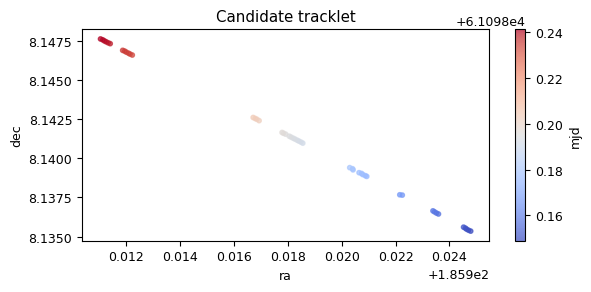

In [75]:
title = 'Candidate tracklet'

plot_scatter(df=df_dets, title=title,
             prop_x='ra', prop_y='dec',
             prop_color='mjd')

We confirm the alignment is also found across individual detections and exposures, making it a promising moving object candidate. We show alert image cutouts for the first 3 detections as

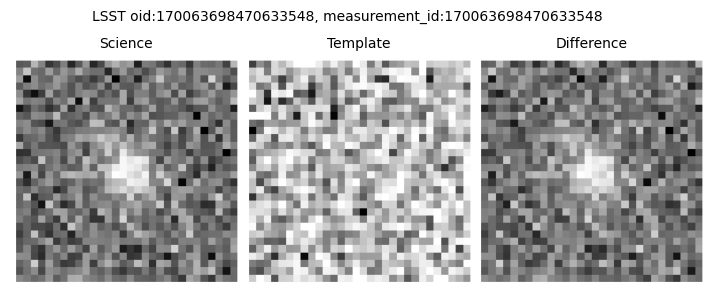

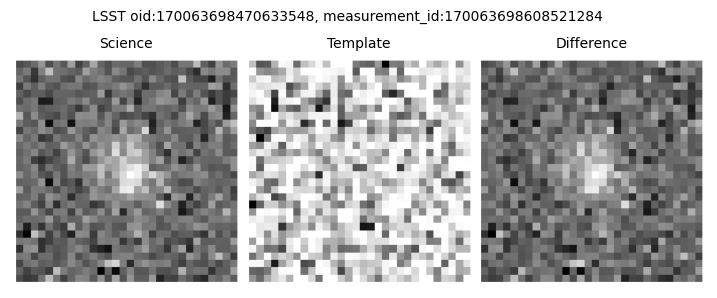

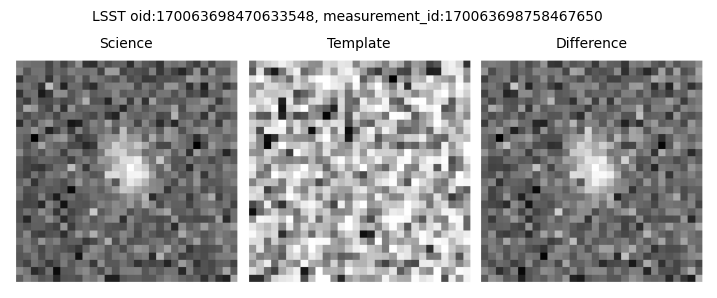

In [76]:
df_dets_this = df_dets.sort_values(by='mjd').iloc[0:3].copy()

for i, row in df_dets_this.iterrows():
    params = {
        'survey': 'lsst',
        'oid': i,
        'measurement_id': row['measurement_id'],
    }
    df_stamps = alerce_client.plot_stamps(**params)

#### Bonus: another inspection  <a class='anchor' id='tracklet_other'></a>

We now zoom in to another of the three regions, towards the EDFS.

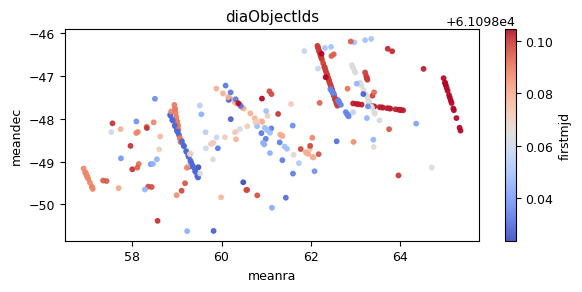

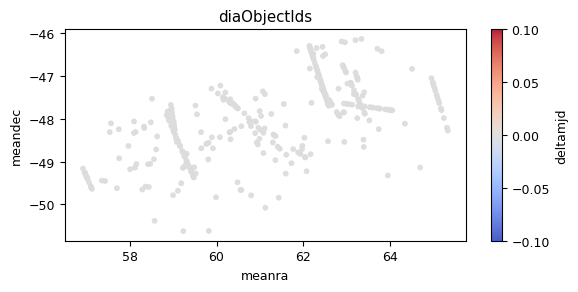

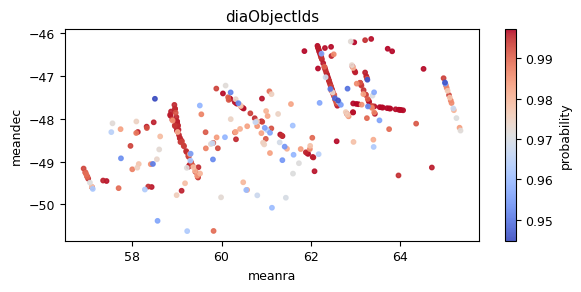

In [77]:
mask = df_objs['meandec'] < -40

props_x = ['meanra', 'meanra', 'meanra']
props_y = ['meandec', 'meandec', 'meandec']
props_color = ['firstmjd', 'deltamjd', 'probability']

title = 'diaObjectIds'

for (prop_x, prop_y, prop_color) in zip(
    props_x, props_y, props_color):
    plot_scatter(df=df_objs[mask], title=title,
                 prop_x=prop_x, prop_y=prop_y,
                 prop_color=prop_color, alpha=0.9)

We distinguish several trails. As before, we select a tentative region

15 diaObjectIds


,oid,meanra,meandec,firstmjd,deltamjd,n_det
195,170063689935224905,64.967980,-47.052885,61098.104437,0.0,1
976,170063689935224861,64.998739,-47.153497,61098.104437,0.0,1
836,170063689935224851,65.006656,-47.179454,61098.104437,0.0,1
290,170063689935224833,65.019431,-47.221014,61098.104437,0.0,1
306,170063689933652057,65.037716,-47.280102,61098.104437,0.0,1
459,170063689933652023,65.058374,-47.347337,61098.104437,0.0,1
213,170063689933651973,65.089343,-47.447839,61098.104437,0.0,1
444,170063689913204802,65.107447,-47.506871,61098.104437,0.0,1
294,170063689913204774,65.128246,-47.573976,61098.104437,0.0,1
316,170063689913204759,65.146455,-47.632915,61098.104437,0.0,1


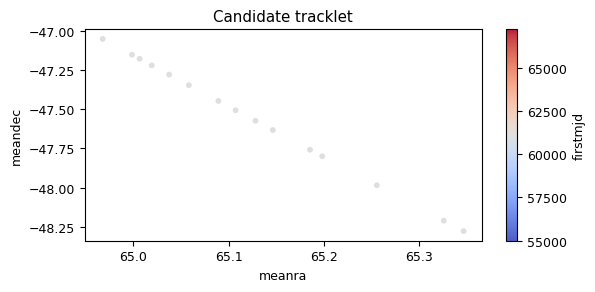

In [78]:
df_track = show_tracklet(
    df=df_objs,
    ra_lims=[64.7, 66],
    dec_lims=[-49, -46],
    show_table=True
)

We notice that in this case, all objects have exactly one detection, and all of them come from the same exposure (implied by their MJD). We query the detections as

In [79]:
index = df_track['oid']
df_dets = find_detections(index=index, sid=sid)

df_dets = add_mapped_column(
    df=df_dets,
    df_lut=df_bands,
    col='band',
    col_mapped='band_name'
)
df_dets.set_index('oid', inplace=True)

In [80]:
display(df_dets[cols_lc])

,sid,measurement_id,band_name,mjd,psfflux,psffluxerr,scienceflux,sciencefluxerr
oid,,,,,,,,
170063689889611849,1,170063689889611849,r,61098.104437,4900.996582,318.083923,4676.953125,320.858307
170063689889611879,1,170063689889611879,r,61098.104437,5586.061523,316.629822,5858.676270,319.965393
170063689910059100,1,170063689910059100,r,61098.104437,5426.499512,308.648712,5547.128418,312.827728
170063689911631935,1,170063689911631935,r,61098.104437,4769.886230,307.200348,4763.412109,311.238007
170063689911631952,1,170063689911631952,r,61098.104437,4719.719238,306.498962,4724.157227,311.062286
170063689913204759,1,170063689913204759,r,61098.104437,5341.509766,309.573669,5498.979980,312.791138
170063689913204774,1,170063689913204774,r,61098.104437,5025.087891,310.252899,5021.264648,313.063171
170063689913204802,1,170063689913204802,r,61098.104437,4446.328613,309.404327,4442.998047,312.368256
170063689933651973,1,170063689933651973,r,61098.104437,4388.491699,295.063354,4659.708008,298.082123


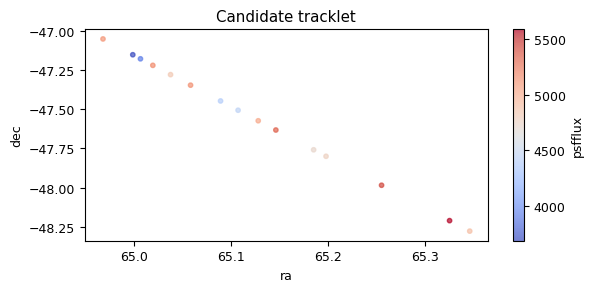

In [81]:
title = 'Candidate tracklet'

plot_scatter(df=df_dets, title=title,
             prop_x='ra', prop_y='dec',
             prop_color='psfflux')

We notice these detections span a range in difference flux densities. We show alert image cutouts for the first 3 detections with lowest declination as

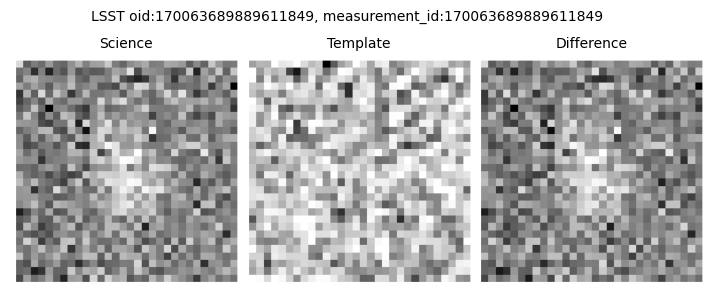

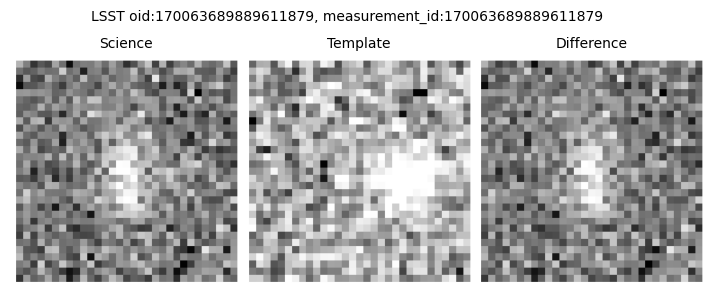

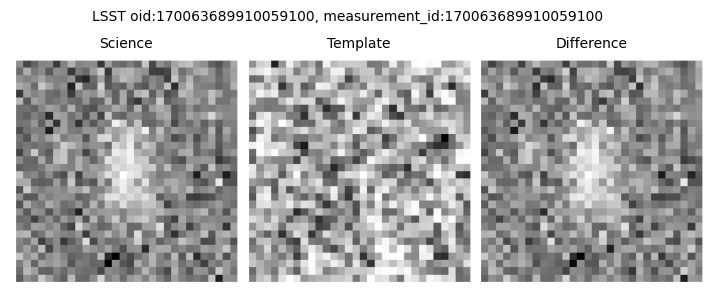

In [82]:
df_dets_this = df_dets.sort_values(by='dec').iloc[0:3].copy()

for i, row in df_dets_this.iterrows():
    params = {
        'survey': 'lsst',
        'oid': i,
        'measurement_id': row['measurement_id'],
    }
    df_stamps = alerce_client.plot_stamps(**params)

These stamps look like glints, making this trail a satellite candidate.